[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/linear_algebra/10_matrix_calculus_graph_and_ai_applications/first_principles.ipynb)

# Module 10 — Matrix Calculus, Graphs, and AI Applications

## 1. Why This Module Exists

A loss in machine learning is a scalar. Its arguments are matrices: weight matrices, covariance
matrices, adjacency matrices. Differentiating a scalar with respect to a matrix by writing
$mn$ separate partial derivatives is correct and unusable.

This module builds the one tool that removes the indices. Write the first-order change of $f$ as
a linear form in the perturbation $dX$, read the gradient off that form, and every identity of
matrix calculus follows in three lines instead of thirty.

The second half applies the same linear algebra to objects that are not obviously analytic. A
graph is a matrix. Its Laplacian turns a combinatorial question — where does this network split
apart? — into an eigenvalue question. A linear dynamical system is a matrix in an exponent.

The payoff is that backpropagation, spectral clustering, PageRank and a damped oscillator are
four readings of the same three theorems. This module proves those theorems and then runs each
application on numbers small enough to check by hand.

## 2. Intuition

Differentiation is linear approximation. For $f : \mathbb{R} \to \mathbb{R}$ the approximation is
$f(x + h) \approx f(x) + f'(x) h$, and $f'(x)$ is a number because the only linear maps
$\mathbb{R} \to \mathbb{R}$ are multiplications.

For $f : \mathbb{R}^{m \times n} \to \mathbb{R}$ the approximation is the same sentence, but the
linear map now eats a whole matrix $dX$ and returns a scalar. There is no single number that
represents it — there is a whole matrix of coefficients.

The trick is that every linear functional on $\mathbb{R}^{m \times n}$ is an inner product against
one fixed matrix. So the first-order change always takes the form
$\operatorname{tr}(G^{\top} dX)$, and $G$ *is* the gradient.

Picture it in two dimensions. The level curves of $f(x) = x^{\top} A x$ are ellipses, and the
gradient at a point is the arrow perpendicular to the ellipse through it. The differential is the
*rule* "project the step onto that arrow"; the gradient is the arrow itself.

Graphs enter through the same door. The Laplacian quadratic form $x^{\top} L x$ is the total
squared disagreement of $x$ across edges, so minimizing it over vectors orthogonal to the
constant one asks the network to split as cleanly as it can.

The first code cell is the notebook preamble. It fixes the plotting defaults, seeds the single
random generator used everywhere below, and prints the machine epsilon that every later residual
claim is measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as sla

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")

machine epsilon = 2.2204e-16


Every residual reported later is quoted as a multiple of this number.

The next cell draws the picture described above for

$$
A = \begin{pmatrix} 2 & 1 \\ 1 & 1 \end{pmatrix}, \qquad f(x) = x^{\top} A x .
$$

It plots the level curves of $f$, overlays the gradient field $\nabla f(x) = (A + A^{\top})x$, and
marks one point $x_0$ with a step $dx$ so that the predicted change
$\operatorname{tr}(\nabla f(x_0)^{\top} dx)$ can be compared against the true change.

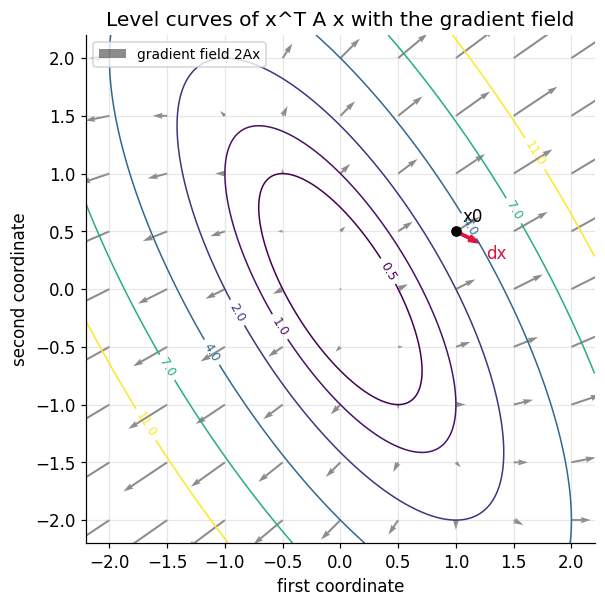

gradient at x0            : [5. 3.]
predicted change  <g, dx> : +0.700000
actual change  f(x0+dx)-f : +0.750000
second-order remainder    : +0.050000   (dx^T A dx = +0.050000)


In [2]:
A2 = np.array([[2.0, 1.0], [1.0, 1.0]])
f2 = lambda z: z @ A2 @ z
grad2 = lambda z: (A2 + A2.T) @ z

g = np.linspace(-2.2, 2.2, 240)
GX, GY = np.meshgrid(g, g)
F = 2 * GX**2 + 2 * GX * GY + GY**2

gq = np.linspace(-2.0, 2.0, 9)
QX, QY = np.meshgrid(gq, gq)
U = 2 * (2 * QX + QY)
V = 2 * (QX + QY)

x0 = np.array([1.0, 0.5])
dx = np.array([0.20, -0.10])
predicted = grad2(x0) @ dx
actual = f2(x0 + dx) - f2(x0)

fig, ax = plt.subplots(figsize=(6.0, 6.0))
cs = ax.contour(GX, GY, F, levels=[0.5, 1, 2, 4, 7, 11], linewidths=1.0)
ax.clabel(cs, inline=True, fontsize=8)
ax.quiver(QX, QY, U, V, alpha=0.45, width=0.004, label="gradient field 2Ax")
ax.plot([x0[0]], [x0[1]], "ko", ms=6)
ax.arrow(x0[0], x0[1], dx[0], dx[1], width=0.02, length_includes_head=True, color="crimson")
ax.annotate("x0", x0 + np.array([0.06, 0.08]))
ax.annotate("dx", x0 + dx + np.array([0.06, -0.14]), color="crimson")
ax.set_aspect("equal")
ax.set_xlabel("first coordinate")
ax.set_ylabel("second coordinate")
ax.set_title("Level curves of x^T A x with the gradient field")
ax.legend(loc="upper left", fontsize=9)
plt.show()

print(f"gradient at x0            : {grad2(x0)}")
print(f"predicted change  <g, dx> : {predicted:+.6f}")
print(f"actual change  f(x0+dx)-f : {actual:+.6f}")
print(f"second-order remainder    : {actual - predicted:+.6f}"
      f"   (dx^T A dx = {dx @ A2 @ dx:+.6f})")

The arrows cross every level curve at a right angle: the gradient is the direction of steepest
increase, and it is perpendicular to the set where $f$ does not change.

At $x_0 = (1, 0.5)$ the gradient is $(A + A^{\top})x_0 = (5, 3)$, and the linear prediction
$\langle \nabla f(x_0), dx \rangle = 0.700000$ misses the true change $0.750000$ by exactly
$dx^{\top} A \, dx = 0.050000$. That leftover is second order in the step, which is the entire
content of the word *differential*.

## 3. Definitions

Vectors are columns, $A^{\top}$ is the transpose, and $\nabla f$ is shaped like the variable it
differentiates. The repository conventions are fixed in
[the notation register](../../docs/notation.md); the two rulings that bind here are that
transition matrices are **column-stochastic** with $P\pi = \pi$, and that graph Laplacian
eigenvalues are listed **ascending**.

> [!NOTE]
> **Ordering exception.** For Laplacian spectra only, this module writes
> $0 = \lambda_1 \le \lambda_2 \le \cdots \le \lambda_n$, the reverse of the repository default,
> so that $\lambda_2$ is the algebraic connectivity and the multiplicity of $0$ counts connected
> components.

### Definition 3.1 — Differential of a matrix function

Let $\mathcal{D} \subseteq \mathbb{R}^{m \times n}$ be open and $f : \mathcal{D} \to \mathbb{R}$.
Then $f$ is **differentiable at $X$** when there is a linear map
$L_X : \mathbb{R}^{m \times n} \to \mathbb{R}$ with

$$
f(X + E) = f(X) + L_X(E) + r(E), \qquad \frac{r(E)}{\lVert E \rVert_F} \to 0 \ \text{ as } \ E \to 0 .
$$

The map $L_X$ is the **differential** of $f$ at $X$, written $df$ or $df(X; E)$.

The remainder condition is what makes $L_X$ unique: two different linear maps cannot both
approximate $f$ to first order.

### Definition 3.2 — Frobenius inner product and the gradient

For $A, B \in \mathbb{R}^{m \times n}$ the **Frobenius inner product** is

$$
\langle A, B \rangle_F = \operatorname{tr}(A^{\top} B) = \sum_{i,j} A_{ij} B_{ij} .
$$

It is a genuine inner product on $\mathbb{R}^{m \times n}$: bilinear, symmetric, and
$\langle A, A \rangle_F = \lVert A \rVert_F^2 \gt 0$ for $A \neq 0$.

The **gradient** $\nabla_X f \in \mathbb{R}^{m \times n}$ is the matrix representing $df$ in this
inner product, so that $df(X; E) = \langle \nabla_X f, E \rangle_F$. Theorem 4.1 says it exists
and is unique.

**Layout, fixed once.** A gradient has the shape of the variable: $\nabla_X f$ is $m \times n$
when $X$ is. The Jacobian of $F : \mathbb{R}^n \to \mathbb{R}^m$ is the $m \times n$ matrix
$(J_F)_{ij} = \partial F_i / \partial x_j$, so $J_f = (\nabla f)^{\top}$ when $m = 1$. Every
gradient below is annotated with its shape.

### Definition 3.3 — vec and the Kronecker product

For $X \in \mathbb{R}^{m \times n}$, $\operatorname{vec}(X) \in \mathbb{R}^{mn}$ stacks the
columns of $X$ on top of one another, first column first.

For $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{p \times q}$ the **Kronecker product**
$A \otimes B \in \mathbb{R}^{mp \times nq}$ is the block matrix whose $(i,j)$ block is
$A_{ij} B$.

Both are bookkeeping devices: they turn a linear map on matrices into an ordinary matrix acting
on a long vector, so that ordinary linear algebra applies.

### Definition 3.4 — Graph matrices

Let $G = (V, E)$ be a finite undirected graph with $n = \lvert V \rvert$, $m = \lvert E \rvert$,
no self-loops, and non-negative edge weights $A_{ij} = A_{ji} \ge 0$.

- the **adjacency matrix** is $A \in \mathbb{R}^{n \times n}$ with $A_{ii} = 0$;
- the **degree** of $i$ is $d_i = \sum_j A_{ij}$ and $D = \operatorname{diag}(d_1, \dots, d_n)$;
- the **combinatorial Laplacian** is $L = D - A$;
- fixing an arbitrary orientation on each edge, the **incidence matrix**
  $B \in \mathbb{R}^{n \times m}$ has $B_{i e} = +\sqrt{A_e}$ at the tail of $e$,
  $-\sqrt{A_e}$ at its head, and $0$ elsewhere.

When every $d_i \gt 0$, the **normalized Laplacians** are

$$
L_{\mathrm{sym}} = D^{-1/2} L D^{-1/2}, \qquad L_{\mathrm{rw}} = D^{-1} L .
$$

### Definition 3.5 — Volume, boundary, conductance

For $S \subseteq V$ write $\bar{S} = V \setminus S$ and

$$
\operatorname{vol}(S) = \sum_{i \in S} d_i, \qquad
\lvert \partial S \rvert = \sum_{i \in S} \sum_{j \in \bar{S}} A_{ij} .
$$

The **conductance** of the graph is

$$
h(G) = \min_{\emptyset \neq S \subsetneq V} \frac{\lvert \partial S \rvert}{\min \lbrace \operatorname{vol}(S), \operatorname{vol}(\bar{S}) \rbrace} .
$$

This is the *normalized* Cheeger constant, and it is the one that pairs with
$\lambda_2(L_{\mathrm{sym}})$ in Theorem 4.6. The unnormalized variant
$\lvert \partial S \rvert / \lvert S \rvert$ pairs with $\lambda_2(L)$ instead, and mixing the two
produces a false inequality.

### Definition 3.6 — Matrix exponential

For $A \in \mathbb{R}^{n \times n}$,

$$
e^{A} = \sum_{k=0}^{\infty} \frac{A^k}{k!} .
$$

Theorem 4.7 shows the series converges for every $A$. It is emphatically **not** the entrywise
exponential: $e^{A} \neq [e^{A_{ij}}]$ except in degenerate cases.

### Definition 3.7 — Column-stochastic, irreducible, primitive

$P \in \mathbb{R}^{n \times n}$ is **column-stochastic** when $P_{ij} \ge 0$ and
$\mathbf{1}^{\top} P = \mathbf{1}^{\top}$, so $P_{ij} = \mathbb{P}(X_{t+1} = i \mid X_t = j)$ and
one step of the chain is $\pi_{t+1} = P \pi_t$.

$P$ is **irreducible** when for every $(i,j)$ there is $k$ with $(P^k)_{ij} \gt 0$, and
**primitive** when a single $k$ works for all entries at once, that is $P^k \gt 0$ entrywise.

A **stationary distribution** is a vector $\pi \ge 0$ with $\mathbf{1}^{\top}\pi = 1$ and
$P\pi = \pi$.

## 4. Main Results

Theorem 4.1 is the engine: it is the result this module is named after, and everything in the
matrix-calculus half is a corollary of it. Theorems 4.2 to 4.4 are those corollaries, ending in
backpropagation.

Theorems 4.5 and 4.6 do the same job for graphs, turning a combinatorial cut into an eigenvalue.
Theorems 4.7 and 4.8 handle the two dynamics, continuous and discrete.

### Theorem 4.1 — First identification theorem

Let $\mathcal{D} \subseteq \mathbb{R}^{m \times n}$ be open and let
$f : \mathcal{D} \to \mathbb{R}$ be differentiable at $X \in \mathcal{D}$. Then there is exactly
one matrix $G \in \mathbb{R}^{m \times n}$ with

$$
df(X; E) = \operatorname{tr}(G^{\top} E) \qquad \text{for every } E \in \mathbb{R}^{m \times n},
$$

and its entries are $G_{ij} = \partial f / \partial X_{ij}$. We write $G = \nabla_X f$.

**Hypotheses.** Differentiability at $X$ is needed for the differential to be a *linear* map: a
function can have all $mn$ partial derivatives at $X$ and still fail to have one, in which case
no single $G$ reproduces the first-order behaviour in every direction. Openness of $\mathcal{D}$
is needed so that $X + E$ stays in the domain for all small $E$ in every direction.

**Consequence, used everywhere below.** To differentiate, do not compute partial derivatives.
Compute $df$ by ordinary algebra, push it into the form $\operatorname{tr}(G^{\top} dX)$, and
read off $G$.

Proved as Proof 5.1. The counterexample $f(X) = \lVert X \rVert_F$ at $X = 0$ is run in
Section 7.3.

### Theorem 4.2 — The four differentials that generate the subject

Let $X$ be a real matrix, and let all products below be conformable.

1. **Product rule.** $d(XY) = (dX)\,Y + X\,(dY)$.
2. **Inverse.** For invertible $X$, $\ d(X^{-1}) = -X^{-1} (dX) X^{-1}$.
3. **Jacobi's formula.** For invertible $X$, $\ d(\det X) = \det(X) \operatorname{tr}(X^{-1} dX)$.
4. **Trace form.** $d\operatorname{tr}(AXB) = \operatorname{tr}(BA\,dX)$.

Reading each through Theorem 4.1 gives, with $X \in \mathbb{R}^{n \times n}$ invertible and
$A \in \mathbb{R}^{p \times m}$, $X \in \mathbb{R}^{m \times n}$, $B \in \mathbb{R}^{n \times p}$
in the last line,

$$
\nabla_X \ln \det X = X^{-\top}, \qquad
\nabla_X \operatorname{tr}(AXB) = A^{\top} B^{\top},
$$

both of the same shape as $X$.

**Hypotheses.** Invertibility in (2) and (3) is what makes the expressions defined at all;
$\ln \det X$ additionally needs $\det X \gt 0$. Nothing here assumes symmetry, and that matters:
if $X$ is *constrained* to be symmetric, the gradient with respect to the free parameters is
$2X^{-1} - \operatorname{diag}(X^{-1})$, not $X^{-1}$.

Proved as Proof 5.2.

### Theorem 4.3 — vec, Kronecker, and the Sylvester equation

For conformable $A$, $X$, $B$,

$$
\operatorname{vec}(AXB) = (B^{\top} \otimes A) \operatorname{vec}(X),
$$

so the Jacobian of the linear map $X \mapsto AXB$ is exactly $B^{\top} \otimes A$.

Consequently, for $A \in \mathbb{R}^{n \times n}$ and $B \in \mathbb{R}^{m \times m}$ the
**Sylvester equation** $AX + XB = C$ is the linear system

$$
\bigl( I_m \otimes A + B^{\top} \otimes I_n \bigr) \operatorname{vec}(X) = \operatorname{vec}(C),
$$

whose coefficient matrix has eigenvalues $\lbrace \alpha_i + \beta_j \rbrace$ over all
$\alpha_i \in \operatorname{spec}(A)$, $\beta_j \in \operatorname{spec}(B)$. Hence the equation
has a unique solution for every $C$ if and only if
$\operatorname{spec}(A) \cap \operatorname{spec}(-B) = \emptyset$.

**Hypotheses.** Only conformability for the first identity. The spectral criterion needs both $A$
and $B$ square, and it is an if-and-only-if: when some $\alpha_i + \beta_j = 0$ the system is
singular and the equation is either unsolvable or has a whole affine family of solutions.

Proved as Proof 5.3.

### Theorem 4.4 — Backpropagation

Consider the feed-forward network

$$
z_k = W_k a_{k-1} + b_k, \qquad a_k = \sigma_k(z_k), \qquad k = 1, \dots, K,
$$

with $a_0 = x$ fixed, $W_k \in \mathbb{R}^{n_k \times n_{k-1}}$, each $\sigma_k$ applied
entrywise and differentiable, and a scalar loss $J = \ell(a_K)$. Write
$\delta_k = \nabla_{z_k} J \in \mathbb{R}^{n_k}$. Then

$$
\delta_K = \sigma_K'(z_K) \odot \nabla_{a_K} \ell, \qquad
\delta_{k-1} = \bigl( W_k^{\top} \delta_k \bigr) \odot \sigma_{k-1}'(z_{k-1}),
$$

and the parameter gradients are

$$
\nabla_{W_k} J = \delta_k a_{k-1}^{\top} \in \mathbb{R}^{n_k \times n_{k-1}}, \qquad
\nabla_{b_k} J = \delta_k \in \mathbb{R}^{n_k} .
$$

**Hypotheses.** Each $\sigma_k$ must be differentiable at the actual pre-activation $z_k$, and
must act entrywise — that is what turns its Jacobian into the diagonal matrix whose action is the
Hadamard product $\odot$. For ReLU the hypothesis fails exactly on the measure-zero set
$z_k = 0$, where implementations substitute a subgradient.

**Interpretation.** The whole algorithm is one outer product per layer and one transposed
matrix-vector product per layer. Nothing else appears.

Proved as Proof 5.4.

### Theorem 4.5 — Structure of the graph Laplacian

Let $G$ be a weighted undirected graph as in Definition 3.4, with Laplacian $L = D - A$ and
incidence matrix $B$. Then

$$
L = B B^{\top}, \qquad
x^{\top} L x = \frac{1}{2}\sum_{i,j} A_{ij}(x_i - x_j)^2 = \sum_{\lbrace i,j \rbrace \in E} A_{ij}(x_i - x_j)^2 \ \ge 0 ,
$$

so $L$ is symmetric positive semidefinite with $L\mathbf{1} = 0$. Moreover

$$
\dim \operatorname{Null}(L) = \text{number of connected components of } G,
$$

and the null space is spanned by the indicator vectors of those components. The same statements
hold for $L_{\mathrm{sym}}$ with $\mathbf{1}$ replaced by $D^{1/2}\mathbf{1}$, and
$\operatorname{spec}(L_{\mathrm{sym}}) \subseteq [0, 2]$.

**Hypotheses.** Non-negative weights are essential: a single negative weight makes the quadratic
form indefinite and destroys every conclusion. Positive degrees are needed for
$L_{\mathrm{sym}}$ to be defined.

Proved as Proof 5.5.

### Theorem 4.6 — Cheeger's inequality

Let $G$ be connected with all $d_i \gt 0$, let $h(G)$ be the conductance of Definition 3.5, and
let $\lambda_2 = \lambda_2(L_{\mathrm{sym}})$ be the second-smallest eigenvalue of the
**symmetric normalized** Laplacian. Then

$$
\frac{\lambda_2}{2} \ \le \ h(G) \ \le \ \sqrt{2 \lambda_2} .
$$

**Hypotheses.** Connectivity makes $\lambda_2 \gt 0$, so the bound says something. The
normalization is not decoration: $h$ is defined with $\operatorname{vol}$ in the denominator
precisely so that it matches $L_{\mathrm{sym}}$. Pairing this $h$ with $\lambda_2(L)$, or the
cut-per-vertex constant with $\lambda_2(L_{\mathrm{sym}})$, gives a statement that is false.

The **left inequality is proved in full** as Proof 5.6.

### Theorem 4.6b (cited, not proved here) — the hard direction of Cheeger

The right-hand bound $h(G) \le \sqrt{2\lambda_2}$ is proved by *sweep-cut rounding*: sort the
vertices by the entries of the Fiedler vector of $L_{\mathrm{sym}}$, take the $n-1$ prefixes of
that order as candidate sets, and show that the best of them already achieves the bound.

Source: Chung, *Spectral Graph Theory*, Ch. 2, section 2.2 (Theorem 2.2 and Lemma 2.1). A
self-contained modern account is in Spielman, *Spectral and Algebraic Graph Theory*, Ch. 21.

Section 7.5 runs the rounding numerically, confirms the sandwich, and shows that on the test
graph the sweep cut finds the exactly optimal set.

### Theorem 4.7 — The matrix exponential

For every $A \in \mathbb{R}^{n \times n}$ the series of Definition 3.6 converges absolutely, and

$$
\frac{d}{dt} e^{At} = A e^{At} = e^{At} A, \qquad e^{A \cdot 0} = I .
$$

Consequently $x(t) = e^{At}x_0$ is the unique solution of $\dot{x} = Ax$, $x(0) = x_0$, and
$e^{At}$ is invertible with inverse $e^{-At}$.

If $AB = BA$ then $e^{A+B} = e^{A}e^{B}$.

**Hypotheses.** Commutation is necessary for the last line, not a convenience. Section 7.3 runs
$A = \left[\begin{smallmatrix}0&1\\0&0\end{smallmatrix}\right]$,
$B = \left[\begin{smallmatrix}0&0\\1&0\end{smallmatrix}\right]$, for which
$e^{A+B}$ and $e^{A}e^{B}$ differ by $0.752$ in Frobenius norm.

Proved as Proof 5.7. The deeper theory — the defective case, Putzer's algorithm,
scaling-and-squaring — is developed in
[differential_equations/04](../../differential_equations/04_systems_of_odes_matrix_exponential/),
which owns that topic; this module keeps only the series and its two consequences.

### Theorem 4.8 — Convergence of a primitive Markov chain

Let $P$ be column-stochastic and primitive, with stationary distribution $\pi$ and second-largest
eigenvalue modulus $\lvert \lambda_2 \rvert$. Then for every distribution $\pi_0$,

$$
P^k \pi_0 \longrightarrow \pi \qquad \text{as } k \to \infty,
$$

and the convergence is geometric: $\lVert P^k \pi_0 - \pi \rVert_2 \le C_\varepsilon (\lvert \lambda_2 \rvert + \varepsilon)^k$
for every $\varepsilon \gt 0$.

**Hypotheses.** Primitivity, not merely irreducibility. The two-state swap
$P = \left[\begin{smallmatrix}0&1\\1&0\end{smallmatrix}\right]$ is irreducible, has the stationary
distribution $(1/2, 1/2)$, and $P^k \pi_0$ oscillates forever; Section 7.3 runs it. Column-
stochasticity supplies $\rho(P) = 1$.

Proved as Proof 5.8, which does **not** assume $P$ is diagonalizable.

### Theorem 4.8b (cited, not proved here) — the Perron half

For a primitive non-negative $P$ with spectral radius $\rho(P)$, the value $\rho(P)$ is an
eigenvalue, it is algebraically simple, its eigenvector may be chosen strictly positive, and every
other eigenvalue satisfies $\lvert \lambda \rvert \lt \rho(P)$.

Source: Horn and Johnson, *Matrix Analysis*, 2nd ed., section 8.2 (Perron's theorem for positive
matrices) and section 8.5 (primitive matrices). Proof 5.8 takes this as given and derives the
convergence statement of Theorem 4.8 from it.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, first identification theorem)

**Step 1 — the differential is a linear functional.** By Definition 3.1 the map
$E \mapsto df(X; E)$ is linear from $\mathbb{R}^{m \times n}$ to $\mathbb{R}$.

**Step 2 — existence.** The space $\mathbb{R}^{m \times n}$ carries the inner product
$\langle \cdot, \cdot \rangle_F$ of Definition 3.2, and $\lbrace E_{ij} \rbrace$ — the matrices
with a single $1$ in position $(i,j)$ — is an orthonormal basis for it.

Define

$$
G = \sum_{i=1}^{m} \sum_{j=1}^{n} df(X; E_{ij}) \, E_{ij} .
$$

For an arbitrary $E = \sum_{ij} E_{ij} \langle E_{ij}, E \rangle_F$, linearity of $df$ gives

$$
df(X; E) = \sum_{ij} \langle E_{ij}, E \rangle_F \, df(X; E_{ij}) = \langle G, E \rangle_F = \operatorname{tr}(G^{\top}E) .
$$

**Step 3 — uniqueness.** If $\operatorname{tr}(G_1^{\top} E) = \operatorname{tr}(G_2^{\top} E)$
for every $E$, then $\langle G_1 - G_2, E \rangle_F = 0$ for every $E$. Taking
$E = G_1 - G_2$ gives $\lVert G_1 - G_2 \rVert_F^2 = 0$, hence $G_1 = G_2$.

**Step 4 — the entries.** Put $E = E_{ij}$ in Definition 3.1 with $E$ replaced by $tE_{ij}$:

$$
f(X + tE_{ij}) = f(X) + t \, \operatorname{tr}(G^{\top}E_{ij}) + r(tE_{ij}),
$$

and $r(tE_{ij})/t \to 0$. Dividing by $t$ and letting $t \to 0$,

$$
\frac{\partial f}{\partial X_{ij}}(X) = \operatorname{tr}(G^{\top} E_{ij}) = G_{ij} . \qquad \blacksquare
$$

**Interpretation.** Step 2 is the finite-dimensional Riesz representation theorem, written out.
The content of the theorem is not that partial derivatives exist — it is that *one* matrix
encodes the response to every direction at once, which is exactly what lets us drop indices.

### Proof 5.2 (of Theorem 4.2, the four differentials)

**(1) Product rule.** Expand the increment and drop the second-order term:

$$
(X + dX)(Y + dY) - XY = (dX)Y + X(dY) + (dX)(dY),
$$

and $\lVert (dX)(dY) \rVert_F \le \lVert dX \rVert_F \lVert dY \rVert_F$ is $o$ of the step size.

**(2) Inverse.** Differentiate the identity $X X^{-1} = I$ with the product rule. The right-hand
side is constant, so

$$
(dX) X^{-1} + X \, d(X^{-1}) = 0 .
$$

Left-multiplying by $X^{-1}$ gives $d(X^{-1}) = -X^{-1}(dX)X^{-1}$.

**(3) Jacobi's formula.** Factor the perturbed determinant:

$$
\det(X + E) = \det\bigl( X (I + X^{-1}E) \bigr) = \det(X) \det(I + X^{-1}E) .
$$

Now expand $\det(I + M)$ for small $M$. Over $\mathbb{C}$ let $\mu_1, \dots, \mu_n$ be the
eigenvalues of $M$ with multiplicity; then

$$
\det(I + M) = \prod_{k=1}^{n} (1 + \mu_k) = 1 + \sum_k \mu_k + \sum_{k \lt l} \mu_k \mu_l + \cdots
= 1 + \operatorname{tr}(M) + R(M),
$$

where every term of $R$ is a product of at least two eigenvalues, so
$\lvert R(M) \rvert \le c_n \lVert M \rVert_F^2$ by $\lvert \mu_k \rvert \le \lVert M \rVert_F$.

Setting $M = X^{-1}E$ and using $\lVert X^{-1}E \rVert_F \le \lVert X^{-1} \rVert_F \lVert E \rVert_F$,

$$
\det(X + E) = \det(X) \bigl( 1 + \operatorname{tr}(X^{-1}E) \bigr) + O(\lVert E \rVert_F^2),
$$

which is Definition 3.1 with $d(\det X) = \det(X)\operatorname{tr}(X^{-1}dX)$.

Composing with $\ln$ — a scalar chain rule, legitimate because $\det X \gt 0$ — gives

$$
d(\ln \det X) = \frac{d(\det X)}{\det X} = \operatorname{tr}(X^{-1}dX) = \operatorname{tr}\bigl( (X^{-\top})^{\top} dX \bigr),
$$

so Theorem 4.1 identifies $\nabla_X \ln \det X = X^{-\top}$.

**(4) Trace form.** Linearity of trace and of the product in $X$ give
$d\operatorname{tr}(AXB) = \operatorname{tr}(A (dX) B)$, and cyclicity moves $B$ to the front:

$$
d\operatorname{tr}(AXB) = \operatorname{tr}(BA\,dX) = \operatorname{tr}\bigl( ((BA)^{\top})^{\top} dX \bigr),
$$

so $\nabla_X \operatorname{tr}(AXB) = (BA)^{\top} = A^{\top}B^{\top}$. $\blacksquare$

**Interpretation.** Every one of these is a two-line computation once the differential replaces
the partial derivative. The index-based derivation of item (3) alone runs to a page of cofactor
expansions.

### Proof 5.3 (of Theorem 4.3, vec, Kronecker and Sylvester)

**Step 1 — the vec identity.** Write $X = [x_1, \dots, x_n]$ by columns and let $b_j$ be the
$j$-th column of $B$. The $j$-th column of $AXB$ is

$$
(AXB)_{:,j} = A X b_j = A \sum_{i} x_i B_{ij} = \sum_i B_{ij} \, A x_i .
$$

Stacking over $j$, the $j$-th block of $\operatorname{vec}(AXB)$ is
$\sum_i B_{ij} A x_i$, that is, the $(j,i)$ block of the acting matrix is $B_{ij} A$.

By Definition 3.3 the matrix whose $(j,i)$ block is $B_{ij}A = (B^{\top})_{ji} A$ is exactly
$B^{\top} \otimes A$, so $\operatorname{vec}(AXB) = (B^{\top} \otimes A)\operatorname{vec}(X)$.

**Step 2 — Sylvester as a linear system.** Apply Step 1 twice, with $B = I_m$ in the first term
and $A = I_n$ in the second:

$$
\operatorname{vec}(AX) = (I_m \otimes A)\operatorname{vec}(X), \qquad
\operatorname{vec}(XB) = (B^{\top} \otimes I_n)\operatorname{vec}(X),
$$

so $AX + XB = C$ becomes $K \operatorname{vec}(X) = \operatorname{vec}(C)$ with
$K = I_m \otimes A + B^{\top} \otimes I_n$.

**Step 3 — the spectrum of $K$.** By Schur triangularization, proved in
[Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb) as Theorem 4.1,
write $A = U T_A U^{\ast}$ and $B^{\top} = V T_B V^{\ast}$ with $U, V$ unitary and
$T_A, T_B$ upper triangular carrying the eigenvalues $\alpha_i$ and $\beta_j$ on their diagonals.

Using $(P \otimes Q)(R \otimes S) = PR \otimes QS$ and
$(P \otimes Q)^{\ast} = P^{\ast} \otimes Q^{\ast}$, the matrix $W = V \otimes U$ is unitary and

$$
W^{\ast} K W = I_m \otimes T_A + T_B \otimes I_n .
$$

A Kronecker product of upper triangular matrices is upper triangular in the block ordering used
by $\operatorname{vec}$, so the right-hand side is upper triangular with diagonal entries
$\alpha_i + \beta_j$ over all pairs. Similar matrices share a spectrum, so
$\operatorname{spec}(K) = \lbrace \alpha_i + \beta_j \rbrace$.

**Step 4 — the criterion.** $K$ is invertible exactly when $0 \notin \operatorname{spec}(K)$,
that is when $\alpha_i \neq -\beta_j$ for all $i, j$, that is when
$\operatorname{spec}(A) \cap \operatorname{spec}(-B) = \emptyset$. $\blacksquare$

### Proof 5.4 (of Theorem 4.4, backpropagation)

Fix $k$ and hold every other parameter constant. All differentials below are with respect to the
quantity named.

**Step 1 — the loss in terms of $z_k$.** By definition of $\delta_k$ and Theorem 4.1 applied in
$\mathbb{R}^{n_k}$,

$$
dJ = \delta_k^{\top} dz_k .
$$

**Step 2 — weight gradient.** With $a_{k-1}$ fixed, $dz_k = (dW_k) a_{k-1}$, so

$$
dJ = \delta_k^{\top} (dW_k) a_{k-1} = \operatorname{tr}\bigl( \delta_k^{\top} (dW_k) a_{k-1} \bigr)
= \operatorname{tr}\bigl( a_{k-1}\delta_k^{\top} \, dW_k \bigr),
$$

the first equality because a scalar equals its own trace and the second by cyclicity. Theorem 4.1
reads off

$$
\nabla_{W_k} J = \bigl( a_{k-1}\delta_k^{\top} \bigr)^{\top} = \delta_k a_{k-1}^{\top} .
$$

**Step 3 — bias gradient.** With $dz_k = db_k$, Step 1 gives $dJ = \delta_k^{\top} db_k$, hence
$\nabla_{b_k} J = \delta_k$.

**Step 4 — the recurrence.** Now vary $a_{k-1}$: $dz_k = W_k \, da_{k-1}$, so

$$
dJ = \delta_k^{\top} W_k \, da_{k-1} = \bigl( W_k^{\top}\delta_k \bigr)^{\top} da_{k-1},
$$

giving $\nabla_{a_{k-1}} J = W_k^{\top}\delta_k$.

Finally $a_{k-1} = \sigma_{k-1}(z_{k-1})$ acts entrywise, so
$da_{k-1} = \sigma_{k-1}'(z_{k-1}) \odot dz_{k-1}$ and

$$
dJ = \bigl( W_k^{\top}\delta_k \bigr)^{\top} \bigl( \sigma_{k-1}'(z_{k-1}) \odot dz_{k-1} \bigr)
= \Bigl( \bigl( W_k^{\top}\delta_k \bigr) \odot \sigma_{k-1}'(z_{k-1}) \Bigr)^{\top} dz_{k-1},
$$

using $u^{\top}(v \odot w) = (u \odot v)^{\top} w$. Comparing with $dJ = \delta_{k-1}^{\top}dz_{k-1}$
gives the stated recurrence. $\blacksquare$

**Interpretation.** The forward pass stores $a_{k-1}$ and $z_k$; the backward pass needs nothing
else. Memory cost is one activation per layer, which is exactly why deep networks are trainable.

### Proof 5.5 (of Theorem 4.5, structure of the Laplacian)

**Step 1 — the factorization.** Fix the orientation used to build $B$. For an edge
$e = \lbrace i, j \rbrace$ oriented $i \to j$, the column $B_{:,e}$ is
$\sqrt{A_{ij}}(e_i - e_j)$. Hence

$$
BB^{\top} = \sum_{e = \lbrace i,j \rbrace \in E} A_{ij} (e_i - e_j)(e_i - e_j)^{\top} .
$$

The $(i,i)$ entry of this sum collects $A_{ij}$ over every edge at $i$, giving $d_i$; the
$(i,j)$ entry with $i \neq j$ picks up $-A_{ij}$ from the single edge $\lbrace i,j \rbrace$. That
is $D - A = L$. The orientation cancels because it appears squared.

**Step 2 — the quadratic form.** From Step 1,

$$
x^{\top} L x = \lVert B^{\top}x \rVert_2^2 = \sum_{e = \lbrace i,j \rbrace} A_{ij}(x_i - x_j)^2 \ \ge 0 .
$$

Counting each unordered pair twice gives the $\tfrac12 \sum_{i,j}$ form. Non-negativity of the
weights is used here and nowhere else, and it is exactly what fails for a signed graph.

**Step 3 — the null space.** $x \in \operatorname{Null}(L)$ iff $x^{\top}Lx = 0$ (because
$L \succeq 0$ and $L = BB^\top$ forces $Lx = 0$ whenever $B^{\top}x = 0$), iff $x_i = x_j$ for
every edge with $A_{ij} \gt 0$, iff $x$ is constant on each connected component.

The space of functions constant on each of $c$ components has dimension $c$, with the component
indicators as a basis. Hence $\dim\operatorname{Null}(L) = c$.

**Step 4 — the normalized version.** $L_{\mathrm{sym}} = D^{-1/2}LD^{-1/2}$ is a congruence, so it
is symmetric positive semidefinite, and $L_{\mathrm{sym}}(D^{1/2}\mathbf{1}) = D^{-1/2}L\mathbf{1} = 0$.
For the upper bound, put $y = D^{1/2}x$ and use $(x_i - x_j)^2 \le 2x_i^2 + 2x_j^2$:

$$
y^{\top}L_{\mathrm{sym}}y = x^{\top}Lx = \sum_{\lbrace i,j \rbrace} A_{ij}(x_i-x_j)^2
\le 2\sum_{\lbrace i,j \rbrace} A_{ij}(x_i^2 + x_j^2) = 2\sum_i d_i x_i^2 = 2\, y^{\top}y,
$$

so every eigenvalue of $L_{\mathrm{sym}}$ lies in $[0,2]$. $\blacksquare$

### Proof 5.6 (of Theorem 4.6, the left half of Cheeger)

**Step 1 — a variational formula for $\lambda_2$.** $L_{\mathrm{sym}}$ is symmetric, so by the
spectral theorem it has an orthonormal eigenbasis $y_1, \dots, y_n$ with
$0 = \lambda_1 \le \lambda_2 \le \cdots$, and $y_1 = D^{1/2}\mathbf{1} / \lVert D^{1/2}\mathbf{1} \rVert$
by Proof 5.5 Step 4 together with connectivity.

For $y = \sum_{k \ge 2} c_k y_k$ orthogonal to $y_1$,

$$
\frac{y^{\top}L_{\mathrm{sym}}y}{y^{\top}y} = \frac{\sum_{k \ge 2}\lambda_k c_k^2}{\sum_{k \ge 2}c_k^2} \ \ge \ \lambda_2,
$$

with equality at $y = y_2$. So $\lambda_2$ is the minimum of the Rayleigh quotient over
$y \perp D^{1/2}\mathbf{1}$. Substituting $y = D^{1/2}x$,

$$
\lambda_2 = \min_{x \,:\, x^{\top}D\mathbf{1} = 0, \ x \neq 0} \frac{x^{\top}Lx}{x^{\top}Dx} .
$$

**Step 2 — the test vector.** Let $S$ attain the minimum in Definition 3.5 and put
$s = \operatorname{vol}(S)$, $\bar{s} = \operatorname{vol}(\bar{S})$. Define

$$
x_i = \begin{cases} \dfrac{1}{s}, & i \in S, \\[4pt] -\dfrac{1}{\bar{s}}, & i \in \bar{S}. \end{cases}
$$

Then the constraint holds:

$$
x^{\top}D\mathbf{1} = \sum_i d_i x_i = \frac{s}{s} - \frac{\bar{s}}{\bar{s}} = 0 .
$$

**Step 3 — numerator and denominator, in full.** Only edges crossing the cut contribute to the
numerator, and each contributes $(1/s + 1/\bar{s})^2$ times its weight:

$$
x^{\top}Lx = \sum_{\lbrace i,j \rbrace \in E} A_{ij}(x_i - x_j)^2
= \lvert \partial S \rvert \left( \frac{1}{s} + \frac{1}{\bar{s}} \right)^{2} .
$$

The denominator is a plain degree-weighted sum of squares:

$$
x^{\top}Dx = \sum_{i \in S} d_i \frac{1}{s^2} + \sum_{i \in \bar{S}} d_i \frac{1}{\bar{s}^2}
= \frac{s}{s^2} + \frac{\bar{s}}{\bar{s}^2} = \frac{1}{s} + \frac{1}{\bar{s}} .
$$

**Step 4 — divide.** One factor of $(1/s + 1/\bar{s})$ cancels:

$$
\lambda_2 \ \le \ \frac{x^{\top}Lx}{x^{\top}Dx} = \lvert \partial S \rvert \left( \frac{1}{s} + \frac{1}{\bar{s}} \right) .
$$

**Step 5 — bound the bracket.** Both $s$ and $\bar{s}$ are at least $\min(s, \bar{s})$, so
$1/s + 1/\bar{s} \le 2 / \min(s,\bar{s})$ and therefore

$$
\lambda_2 \ \le \ \frac{2 \lvert \partial S \rvert}{\min(s, \bar{s})} = 2 h(G),
$$

which is $\lambda_2 / 2 \le h(G)$. $\blacksquare$

**Interpretation.** The proof is a single well-chosen test vector: a good cut *is* a low-energy
signal, so a good cut forces $\lambda_2$ down. The converse — that a small $\lambda_2$ forces a
good cut to exist — is the hard direction of Theorem 4.6b, and it needs rounding, not a test
vector.

### Proof 5.7 (of Theorem 4.7, the matrix exponential)

**Step 1 — convergence.** The operator norm is submultiplicative, so
$\lVert A^k \rVert_{\mathrm{op}} \le \lVert A \rVert_{\mathrm{op}}^k$ and

$$
\sum_{k=0}^{\infty} \frac{\lVert A^k \rVert_{\mathrm{op}}}{k!} \le e^{\lVert A \rVert_{\mathrm{op}}} \lt \infty .
$$

The partial sums are therefore Cauchy in the complete space
$(\mathbb{R}^{n \times n}, \lVert \cdot \rVert_{\mathrm{op}})$, and the series converges. The
same bound applied to $At$ shows the convergence is uniform for $t$ in any bounded interval.

**Step 2 — differentiation.** Uniform convergence on compact $t$-intervals of the series and of
its termwise derivative permits differentiating term by term:

$$
\frac{d}{dt} e^{At} = \sum_{k=1}^{\infty} \frac{k A^k t^{k-1}}{k!} = A\sum_{k=1}^{\infty}\frac{(At)^{k-1}}{(k-1)!} = A e^{At},
$$

and pulling $A$ out on the right instead gives $e^{At}A$.

**Step 3 — uniqueness of the IVP solution.** Let $x$ solve $\dot{x} = Ax$, $x(0) = x_0$, and set
$w(t) = e^{-At}x(t)$. By Step 2 and the product rule,

$$
\dot{w} = -Ae^{-At}x + e^{-At}\dot{x} = -Ae^{-At}x + e^{-At}Ax = 0,
$$

using that $A$ commutes with its own exponential. So $w$ is constant, $w(t) = w(0) = x_0$, and
$x(t) = e^{At}x_0$. Taking $x_0$ through the standard basis and $t \mapsto -t$ shows
$e^{At}e^{-At} = I$.

**Step 4 — the commuting case.** If $AB = BA$ then the binomial theorem holds for $(A+B)^k$, so

$$
e^{A+B} = \sum_{k=0}^{\infty}\frac{1}{k!}\sum_{j=0}^{k}\binom{k}{j}A^{j}B^{k-j}
= \sum_{j=0}^{\infty}\sum_{l=0}^{\infty} \frac{A^{j}}{j!}\frac{B^{l}}{l!} = e^{A}e^{B},
$$

the rearrangement being legitimate by the absolute convergence of Step 1. $\blacksquare$

**Interpretation.** Step 4 is the only place commutation is used, and it is used essentially:
without it the double sum cannot be split, and Section 7.3 shows the conclusion genuinely fails.

### Proof 5.8 (of Theorem 4.8, convergence of a primitive chain)

Let $\pi$ be the Perron vector of Theorem 4.8b normalized by $\mathbf{1}^{\top}\pi = 1$, so
$P\pi = \pi$ and $\pi \gt 0$.

**Step 1 — a rank-one correction.** Put $Q = P - \pi\mathbf{1}^{\top}$. Using
$\mathbf{1}^{\top}P = \mathbf{1}^{\top}$, $P\pi = \pi$ and $\mathbf{1}^{\top}\pi = 1$,

$$
Q^2 = P^2 - P\pi\mathbf{1}^{\top} - \pi\mathbf{1}^{\top}P + \pi(\mathbf{1}^{\top}\pi)\mathbf{1}^{\top}
= P^2 - \pi\mathbf{1}^{\top},
$$

and the same computation by induction gives $Q^k = P^k - \pi\mathbf{1}^{\top}$ for all $k \ge 1$.

**Step 2 — the spectrum of $Q$.** $\pi\mathbf{1}^{\top}$ is the projection onto
$\operatorname{span}(\pi)$ along $\lbrace v : \mathbf{1}^{\top}v = 0 \rbrace$, and both subspaces
are $P$-invariant. On $\operatorname{span}(\pi)$, $Q\pi = \pi - \pi = 0$; on the complement,
$Q$ agrees with $P$. Hence

$$
\operatorname{spec}(Q) = \lbrace 0 \rbrace \cup \bigl( \operatorname{spec}(P) \setminus \lbrace 1 \rbrace \bigr),
\qquad \rho(Q) = \lvert \lambda_2 \rvert \lt 1
$$

by Theorem 4.8b.

**Step 3 — spectral radius less than one forces decay, with no diagonalizability.** Let
$M \in \mathbb{C}^{n \times n}$ have $\rho(M) \lt 1$. By Schur triangularization write
$M = UTU^{\ast}$ with $T$ upper triangular. For $\eta \gt 0$ put
$D_\eta = \operatorname{diag}(1, \eta, \dots, \eta^{n-1})$; then

$$
(D_\eta^{-1} T D_\eta)_{ij} = \eta^{\,j-i} T_{ij},
$$

so the strictly upper triangular entries are multiplied by positive powers of $\eta$ and can be
made as small as we like. Choosing $\eta$ small enough gives

$$
\lVert D_\eta^{-1} T D_\eta \rVert_{\mathrm{op}} \le \rho(M) + \varepsilon \lt 1
$$

for any prescribed $\varepsilon$ with $\rho(M) + \varepsilon \lt 1$. Writing $S = UD_\eta$,

$$
\lVert M^k \rVert_{\mathrm{op}} = \lVert S (D_\eta^{-1}TD_\eta)^{k} S^{-1} \rVert_{\mathrm{op}}
\le \kappa(S) \, (\rho(M) + \varepsilon)^{k} \longrightarrow 0 .
$$

**Step 4 — conclusion.** Apply Step 3 to $Q$. For any distribution $\pi_0$ we have
$\mathbf{1}^{\top}\pi_0 = 1$, so $\pi\mathbf{1}^{\top}\pi_0 = \pi$ and Step 1 gives

$$
P^k \pi_0 - \pi = \bigl( P^k - \pi\mathbf{1}^{\top} \bigr)\pi_0 = Q^k \pi_0 ,
$$

whence $\lVert P^k\pi_0 - \pi \rVert_2 \le \kappa(S)(\lvert \lambda_2 \rvert + \varepsilon)^k \lVert \pi_0 \rVert_2 \to 0$.
$\blacksquare$

**Interpretation.** No eigenbasis was assumed anywhere. Step 3 is the replacement for the usual
"expand $\pi_0$ in eigenvectors" argument, which is invalid for a defective $P$ — and a primitive
stochastic matrix may certainly be defective.

## 6. Worked Examples

One fully computed example per main theorem, all on objects small enough to finish with a pen.
Two code cells then recompute every number and assert agreement.

### Example 6.1 — Reading gradients off differentials (Theorems 4.1 and 4.2)

Take the symmetric positive definite

$$
X = \begin{pmatrix} 2 & 1 \\ 1 & 3 \end{pmatrix}, \qquad \det X = 6 - 1 = 5 .
$$

*Log-determinant.* $\ln \det X = \ln 5 \approx 1.609438$, and

$$
X^{-1} = \frac{1}{5}\begin{pmatrix} 3 & -1 \\ -1 & 2 \end{pmatrix}
= \begin{pmatrix} 0.6 & -0.2 \\ -0.2 & 0.4 \end{pmatrix} .
$$

$X$ is symmetric, so $X^{-\top} = X^{-1}$ and Theorem 4.2 gives

$$
\nabla_X \ln \det X = \begin{pmatrix} 0.6 & -0.2 \\ -0.2 & 0.4 \end{pmatrix} .
$$

*The symmetric-constraint trap.* If $X$ is treated as a symmetric matrix with three free
parameters $(X_{11}, X_{12}, X_{22})$, then perturbing $X_{12}$ moves two entries at once, so the
derivative with respect to that free parameter is $2(X^{-1})_{12} = -0.4$, not $-0.2$. The
unconstrained gradient and the constrained one differ off the diagonal by a factor of two.

*Trace form.* With

$$
A = \begin{pmatrix} 1 & 2 \\ 0 & 1 \end{pmatrix}, \qquad B = \begin{pmatrix} 0 & 1 \\ 1 & 1 \end{pmatrix},
$$

Theorem 4.2 gives

$$
\nabla_X \operatorname{tr}(AXB) = A^{\top}B^{\top}
= \begin{pmatrix} 1 & 0 \\ 2 & 1 \end{pmatrix}\begin{pmatrix} 0 & 1 \\ 1 & 1 \end{pmatrix}
= \begin{pmatrix} 0 & 1 \\ 1 & 3 \end{pmatrix} .
$$

**Interpretation.** The gradient of a trace form does not involve $X$ at all, because the function
is linear in $X$ — the same reason $\nabla_x (a^{\top}x) = a$ in one dimension.

### Example 6.2 — vec, Kronecker and a Sylvester equation by hand (Theorem 4.3)

*The vec identity.* Take

$$
A = \begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix}, \qquad
X = \begin{pmatrix} 1 & -1 \\ 0 & 2 \end{pmatrix}, \qquad
B = \begin{pmatrix} 2 & 0 \\ 1 & 1 \end{pmatrix} .
$$

Then $AX = \begin{pmatrix} 1 & 3 \\ 3 & 5 \end{pmatrix}$ and

$$
AXB = \begin{pmatrix} 1 & 3 \\ 3 & 5 \end{pmatrix}\begin{pmatrix} 2 & 0 \\ 1 & 1 \end{pmatrix}
= \begin{pmatrix} 5 & 3 \\ 11 & 5 \end{pmatrix}, \qquad
\operatorname{vec}(AXB) = (5, 11, 3, 5)^{\top} .
$$

The other route stacks $\operatorname{vec}(X) = (1, 0, -1, 2)^{\top}$ and multiplies by
$B^{\top} \otimes A$, which is the $4 \times 4$ block matrix
$\left[\begin{smallmatrix} 2A & A \\ 0 & A \end{smallmatrix}\right]$, giving the same
$(5, 11, 3, 5)^{\top}$.

*Sylvester.* Solve $AX + XB = I$ for

$$
A = \begin{pmatrix} 1 & 2 \\ 0 & 3 \end{pmatrix}, \qquad B = \begin{pmatrix} 2 & 0 \\ 1 & 4 \end{pmatrix} .
$$

Here $\operatorname{spec}(A) = \lbrace 1, 3 \rbrace$ and $\operatorname{spec}(-B) = \lbrace -2, -4 \rbrace$
are disjoint, so Theorem 4.3 promises exactly one solution. Writing the four scalar equations,

$$
3x_{11} + x_{12} + 2x_{21} = 1, \qquad 5x_{12} + 2x_{22} = 0, \qquad
5x_{21} + x_{22} = 0, \qquad 7x_{22} = 1 .
$$

Back-substituting from the last equation gives $x_{22} = \tfrac17$, then
$x_{21} = -\tfrac1{35}$, $x_{12} = -\tfrac2{35}$ and $x_{11} = \tfrac{13}{35}$:

$$
X = \frac{1}{35}\begin{pmatrix} 13 & -2 \\ -1 & 5 \end{pmatrix} .
$$

**Interpretation.** The Kronecker form is what makes the count obvious: four unknowns, four
equations, and invertibility decided entirely by the two spectra.

### Example 6.3 — Backpropagation through a two-layer network (Theorem 4.4)

Take $\sigma_1 = \operatorname{ReLU}$, a linear output layer, and squared loss
$J = \tfrac12 (z_2 - t)^2$ with target $t = 4$ and input $x = (1, 2)^{\top}$:

$$
W_1 = \begin{pmatrix} 1 & 1 \\ 2 & -1 \end{pmatrix}, \quad b_1 = \begin{pmatrix} 0 \\ 1 \end{pmatrix},
\qquad W_2 = \begin{pmatrix} 2 & -1 \end{pmatrix}, \quad b_2 = 1 .
$$

*Forward pass.*

$$
z_1 = W_1 x + b_1 = \begin{pmatrix} 3 \\ 1 \end{pmatrix}, \qquad
a_1 = \operatorname{ReLU}(z_1) = \begin{pmatrix} 3 \\ 1 \end{pmatrix}, \qquad
z_2 = 2 \cdot 3 - 1 \cdot 1 + 1 = 6 .
$$

Both entries of $z_1$ are strictly positive, so $\sigma_1'(z_1) = (1,1)^{\top}$ and the
differentiability hypothesis of Theorem 4.4 holds at this input. The loss is
$J = \tfrac12(6-4)^2 = 2$.

*Backward pass.* The output layer is linear, so $\delta_2 = z_2 - t = 2$ and

$$
\nabla_{W_2}J = \delta_2 a_1^{\top} = \begin{pmatrix} 6 & 2 \end{pmatrix}, \qquad \nabla_{b_2}J = 2 .
$$

Propagating back,

$$
\delta_1 = \bigl( W_2^{\top}\delta_2 \bigr) \odot \sigma_1'(z_1)
= \begin{pmatrix} 4 \\ -2 \end{pmatrix} \odot \begin{pmatrix} 1 \\ 1 \end{pmatrix}
= \begin{pmatrix} 4 \\ -2 \end{pmatrix},
$$

and therefore

$$
\nabla_{W_1}J = \delta_1 x^{\top} = \begin{pmatrix} 4 & 8 \\ -2 & -4 \end{pmatrix}, \qquad
\nabla_{b_1}J = \begin{pmatrix} 4 \\ -2 \end{pmatrix} .
$$

**Interpretation.** Every gradient is an outer product of a backward signal with a forward
activation. That single sentence is the whole algorithm, and Section 7.4 checks all eight numbers
against finite differences.

### Example 6.4 — The path graph on four vertices (Theorems 4.5 and 4.6)

Let $G$ be the path $1 - 2 - 3 - 4$ with unit weights. Then

$$
A = \begin{pmatrix} 0&1&0&0 \\ 1&0&1&0 \\ 0&1&0&1 \\ 0&0&1&0 \end{pmatrix}, \quad
D = \operatorname{diag}(1,2,2,1), \quad
L = \begin{pmatrix} 1&-1&0&0 \\ -1&2&-1&0 \\ 0&-1&2&-1 \\ 0&0&-1&1 \end{pmatrix} .
$$

*Spectrum of $L$.* The characteristic polynomial factors as
$\det(zI - L) = z(z-2)(z^2 - 4z + 2)$, whose roots are

$$
\operatorname{spec}(L) = \lbrace 0, \ 2-\sqrt{2}, \ 2, \ 2+\sqrt{2} \rbrace
\approx \lbrace 0, \ 0.585786, \ 2, \ 3.414214 \rbrace .
$$

The Fiedler vector for $\lambda_2 = 2 - \sqrt{2}$ is
$v_2 \propto \bigl( \cos\tfrac{\pi}{8}, \cos\tfrac{3\pi}{8}, \cos\tfrac{5\pi}{8}, \cos\tfrac{7\pi}{8} \bigr)$,
whose sign pattern $(+,+,-,-)$ cuts the path in the middle.

*Normalized Laplacian.* $D^{-1/2}AD^{-1/2}$ has off-diagonal entries
$1/\sqrt{2}, \ 1/2, \ 1/\sqrt{2}$, and its eigenvalues are $\pm 1, \pm \tfrac12$. Hence

$$
\operatorname{spec}(L_{\mathrm{sym}}) = \lbrace 0, \ \tfrac12, \ \tfrac32, \ 2 \rbrace,
\qquad \lambda_2(L_{\mathrm{sym}}) = \tfrac12 .
$$

*Conductance.* Total volume is $\operatorname{vol}(V) = 1+2+2+1 = 6 = 2\lvert E \rvert$. The cut
$S = \lbrace 1,2 \rbrace$ has $\lvert \partial S \rvert = 1$ and
$\operatorname{vol}(S) = \operatorname{vol}(\bar S) = 3$, so its ratio is $\tfrac13$; enumerating
all $2^4 - 2 = 14$ non-trivial subsets shows no cut does better, so $h(G) = \tfrac13$.

*Cheeger check.* Theorem 4.6 predicts

$$
\frac{\lambda_2}{2} = \frac14 \ \le \ h(G) = \frac13 \ \le \ \sqrt{2\lambda_2} = 1 .
$$

*The test vector of Proof 5.6.* With $s = \bar{s} = 3$ it is $x = \tfrac13(1,1,-1,-1)^{\top}$,
giving $x^{\top}Lx = 1 \cdot (\tfrac13 + \tfrac13)^2 = \tfrac49$ and
$x^{\top}Dx = \tfrac13 + \tfrac13 = \tfrac23$, hence the ratio $\tfrac23 = 2h(G)$ exactly as
Step 5 of the proof predicts — and indeed $\lambda_2 = \tfrac12 \le \tfrac23$.

**Interpretation.** The test vector is not optimal here: it gives $2/3$, whereas the true minimum
is $1/2$. Proof 5.6 only ever claimed an upper bound, and the slack is the factor $2$ in
$\lambda_2 / 2 \le h(G)$.

### Example 6.5 — Two matrix exponentials by hand (Theorem 4.7)

*Rotation generator.* Let
$A = \left[\begin{smallmatrix} 0 & -1 \\ 1 & 0 \end{smallmatrix}\right]$. Then $A^2 = -I$, so
$A^{2k} = (-1)^k I$ and $A^{2k+1} = (-1)^k A$. Splitting the series into even and odd terms,

$$
e^{At} = \sum_{k=0}^{\infty}\frac{(-1)^k t^{2k}}{(2k)!} I + \sum_{k=0}^{\infty}\frac{(-1)^k t^{2k+1}}{(2k+1)!} A
= (\cos t) I + (\sin t) A = \begin{pmatrix} \cos t & -\sin t \\ \sin t & \cos t \end{pmatrix} .
$$

The eigenvalues of $A$ are $\pm i$, and the solution of $\dot{x} = Ax$ is a rigid rotation at unit
angular speed — an undamped oscillator.

*Defective generator.* Let
$N = \left[\begin{smallmatrix} 2 & 1 \\ 0 & 2 \end{smallmatrix}\right] = 2I + E_{12}$. The two
summands commute and $E_{12}^2 = 0$, so Theorem 4.7 applies and

$$
e^{Nt} = e^{2It}e^{E_{12}t} = e^{2t}\begin{pmatrix} 1 & t \\ 0 & 1 \end{pmatrix} .
$$

At $t = 1$ this is $e^2 \left[\begin{smallmatrix} 1 & 1 \\ 0 & 1 \end{smallmatrix}\right]
\approx \left[\begin{smallmatrix} 7.389056 & 7.389056 \\ 0 & 7.389056 \end{smallmatrix}\right]$.

**Interpretation.** The repeated eigenvalue with a single eigenvector produces the factor $t$:
solutions grow like $t e^{2t}$, not $e^{2t}$. That polynomial factor is invisible in the spectrum
and is exactly what an eigenbasis argument would miss.

### Example 6.6 — A three-state chain with an exact answer (Theorem 4.8)

Fix $\pi = \bigl(\tfrac12, \tfrac13, \tfrac16\bigr)^{\top}$ and build the *lazy teleporting* chain

$$
P = \tfrac12 \pi \mathbf{1}^{\top} + \tfrac12 I
= \begin{pmatrix} 3/4 & 1/4 & 1/4 \\ 1/6 & 2/3 & 1/6 \\ 1/12 & 1/12 & 7/12 \end{pmatrix} .
$$

*Column-stochastic.* Each column of $\tfrac12\pi\mathbf{1}^{\top}$ sums to $\tfrac12$ and each
column of $\tfrac12 I$ sums to $\tfrac12$, so $\mathbf{1}^{\top}P = \mathbf{1}^{\top}$. Every
entry is positive, so $P$ is primitive with $k = 1$.

*Spectrum.* The rank-one matrix $\pi\mathbf{1}^{\top}$ has eigenvalues
$\mathbf{1}^{\top}\pi = 1$ and $0, 0$. Hence

$$
\operatorname{spec}(P) = \lbrace \tfrac12 \cdot 1 + \tfrac12, \ \tfrac12 \cdot 0 + \tfrac12, \ \tfrac12 \cdot 0 + \tfrac12 \rbrace
= \lbrace 1, \ \tfrac12, \ \tfrac12 \rbrace, \qquad \lvert \lambda_2 \rvert = \tfrac12 .
$$

*Stationary vector.* $P\pi = \tfrac12\pi(\mathbf{1}^{\top}\pi) + \tfrac12\pi = \pi$, so
$\pi$ is stationary — and it is unique by Theorem 4.8b.

*Exact error decay.* Here $Q = P - \pi\mathbf{1}^{\top} = \tfrac12\bigl(I - \pi\mathbf{1}^{\top}\bigr)$,
which acts as multiplication by $\tfrac12$ on $\lbrace v : \mathbf{1}^{\top}v = 0 \rbrace$.
Starting from $\pi_0 = e_1$, Proof 5.8 Step 4 gives the *exact* identity

$$
P^k e_1 - \pi = \left(\tfrac12\right)^{k}(e_1 - \pi),
$$

so $\lVert P^k e_1 - \pi \rVert_2 = (1/2)^k \cdot 0.311805$ for every $k$. At $k = 3$ this is
$0.038976$ and $P^3 e_1 = (0.5625, \ 0.291667, \ 0.145833)^{\top}$.

**Interpretation.** The bound of Theorem 4.8 is attained, not merely satisfied: here the second
eigenvalue is the exact per-step contraction factor, because the whole non-stationary part of the
spectrum sits at $\tfrac12$.

The next cell recomputes Examples 6.1, 6.2 and 6.3 and asserts every stated number, including
the eight backpropagation gradients against a finite-difference reference.

In [3]:
# --- Example 6.1 ---------------------------------------------------------
X61 = np.array([[2.0, 1.0], [1.0, 3.0]])
A61 = np.array([[1.0, 2.0], [0.0, 1.0]])
B61 = np.array([[0.0, 1.0], [1.0, 1.0]])

print("Example 6.1")
print("  det X                 :", np.linalg.det(X61))
print("  grad log det X = X^-T :\n", np.linalg.inv(X61).T)
print("  grad tr(A X B) = A^T B^T:\n", A61.T @ B61.T)
assert abs(np.linalg.det(X61) - 5.0) < 1e-12
assert np.allclose(np.linalg.inv(X61).T, [[0.6, -0.2], [-0.2, 0.4]])
assert np.allclose(A61.T @ B61.T, [[0.0, 1.0], [1.0, 3.0]])

# --- Example 6.2 ---------------------------------------------------------
A62 = np.array([[1.0, 2.0], [3.0, 4.0]])
X62 = np.array([[1.0, -1.0], [0.0, 2.0]])
B62 = np.array([[2.0, 0.0], [1.0, 1.0]])
vec = lambda M: M.reshape(-1, order="F")
lhs = vec(A62 @ X62 @ B62)
rhs = np.kron(B62.T, A62) @ vec(X62)

Asy = np.array([[1.0, 2.0], [0.0, 3.0]])
Bsy = np.array([[2.0, 0.0], [1.0, 4.0]])
Csy = np.eye(2)
Ksy = np.kron(np.eye(2), Asy) + np.kron(Bsy.T, np.eye(2))
Xsy = np.linalg.solve(Ksy, vec(Csy)).reshape(2, 2, order="F")
Xhand = np.array([[13.0, -2.0], [-1.0, 5.0]]) / 35.0

print("\nExample 6.2")
print("  vec(AXB)              :", lhs)
print("  (B^T kron A) vec(X)   :", rhs)
print("  spec(A), spec(-B)     :", np.linalg.eigvals(Asy), np.linalg.eigvals(-Bsy))
print("  Sylvester solution    :\n", Xsy)
print("  hand solution (1/35)*[[13,-2],[-1,5]]:\n", Xhand)
print("  residual ||A X + X B - C||_F =", np.linalg.norm(Asy @ Xsy + Xsy @ Bsy - Csy))
assert np.allclose(lhs, [5.0, 11.0, 3.0, 5.0])
assert np.allclose(lhs, rhs)
assert np.allclose(Xsy, Xhand)

# --- Example 6.3 ---------------------------------------------------------
x63 = np.array([1.0, 2.0])
W1 = np.array([[1.0, 1.0], [2.0, -1.0]])
b1 = np.array([0.0, 1.0])
W2 = np.array([[2.0, -1.0]])
b2 = np.array([1.0])
t63 = 4.0


def forward(W1, b1, W2, b2):
    z1 = W1 @ x63 + b1
    a1 = np.maximum(z1, 0.0)
    z2 = W2 @ a1 + b2
    return z1, a1, z2, 0.5 * (z2[0] - t63) ** 2


z1, a1, z2, J = forward(W1, b1, W2, b2)
delta2 = np.array([z2[0] - t63])
gW2, gb2 = np.outer(delta2, a1), delta2
delta1 = (W2.T @ delta2) * (z1 > 0)
gW1, gb1 = np.outer(delta1, x63), delta1

print("\nExample 6.3")
print(f"  z1 = {z1}   a1 = {a1}   z2 = {z2[0]}   J = {J}")
print("  delta1 =", delta1, "  delta2 =", delta2)
print("  grad W1 =\n", gW1)
print("  grad W2 =", gW2, "  grad b1 =", gb1, "  grad b2 =", gb2)
assert np.allclose(z1, [3.0, 1.0]) and abs(J - 2.0) < 1e-12
assert np.allclose(gW1, [[4.0, 8.0], [-2.0, -4.0]])
assert np.allclose(gW2, [[6.0, 2.0]]) and np.allclose(gb1, [4.0, -2.0])

h = 1e-6
fd_W1 = np.zeros_like(W1)
for i in range(2):
    for j in range(2):
        Ep = np.zeros_like(W1)
        Ep[i, j] = h
        fd_W1[i, j] = (forward(W1 + Ep, b1, W2, b2)[3] - forward(W1 - Ep, b1, W2, b2)[3]) / (2 * h)
print("  central-difference grad W1 =\n", fd_W1)
print(f"  max |backprop - finite difference| = {np.abs(fd_W1 - gW1).max():.3e}")
assert np.abs(fd_W1 - gW1).max() < 1e-6
print("\nall assertions passed")

Example 6.1
  det X                 : 5.000000000000001
  grad log det X = X^-T :
 [[ 0.6 -0.2]
 [-0.2  0.4]]
  grad tr(A X B) = A^T B^T:
 [[0. 1.]
 [1. 3.]]

Example 6.2
  vec(AXB)              : [ 5. 11.  3.  5.]
  (B^T kron A) vec(X)   : [ 5. 11.  3.  5.]
  spec(A), spec(-B)     : [1. 3.] [-4. -2.]
  Sylvester solution    :
 [[ 0.3714 -0.0571]
 [-0.0286  0.1429]]
  hand solution (1/35)*[[13,-2],[-1,5]]:
 [[ 0.3714 -0.0571]
 [-0.0286  0.1429]]
  residual ||A X + X B - C||_F = 0.0

Example 6.3
  z1 = [3. 1.]   a1 = [3. 1.]   z2 = 6.0   J = 2.0
  delta1 = [ 4. -2.]   delta2 = [2.]
  grad W1 =
 [[ 4.  8.]
 [-2. -4.]]
  grad W2 = [[6. 2.]]   grad b1 = [ 4. -2.]   grad b2 = [2.]
  central-difference grad W1 =
 [[ 4.  8.]
 [-2. -4.]]
  max |backprop - finite difference| = 6.701e-10

all assertions passed


Every hand-computed number reappears: $\det X = 5$, the two gradients of Example 6.1, both routes
to $\operatorname{vec}(AXB) = (5,11,3,5)$, the Sylvester solution $\tfrac{1}{35}[[13,-2],[-1,5]]$
with zero residual, and all eight network gradients.

The finite-difference check on $\nabla_{W_1}J$ agrees with backpropagation to about $10^{-9}$,
which is the accuracy floor of a central difference at step $10^{-6}$ — the two computations are
independent, and they meet.

The next cell recomputes Examples 6.4, 6.5 and 6.6: the path-graph spectra, the conductance by
brute-force enumeration over all $14$ cuts, both matrix exponentials, and the exact geometric
decay of the three-state chain.

In [4]:
from itertools import combinations

# --- Example 6.4 ---------------------------------------------------------
A64 = np.array([[0.0, 1, 0, 0], [1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0]])
deg = A64.sum(axis=1)
D64 = np.diag(deg)
L64 = D64 - A64
Dm = np.diag(1.0 / np.sqrt(deg))
Lsym = Dm @ L64 @ Dm

lamL = np.linalg.eigvalsh(L64)
lamS = np.linalg.eigvalsh(Lsym)
_, VL = np.linalg.eigh(L64)
fiedler = VL[:, 1]

print("Example 6.4")
print("  spec(L)               :", lamL)
print("  closed form           :", np.array([0.0, 2 - np.sqrt(2), 2.0, 2 + np.sqrt(2)]))
print("  Fiedler vector        :", fiedler, "  signs", np.sign(fiedler).astype(int))
print("  spec(L_sym)           :", lamS)

best = None
for r in range(1, 4):
    for S in combinations(range(4), r):
        S = set(S)
        Sb = set(range(4)) - S
        cut = sum(A64[i, j] for i in S for j in Sb)
        vS, vSb = sum(deg[i] for i in S), sum(deg[i] for i in Sb)
        ratio = cut / min(vS, vSb)
        if best is None or ratio < best[0] - 1e-15:
            best = (ratio, sorted(S), cut, vS, vSb)
print(f"  conductance h(G)      : {best[0]:.6f}  attained by S = {best[1]}"
      f"  (cut {best[2]:.0f}, vol {best[3]:.0f}/{best[4]:.0f})")
print(f"  Cheeger sandwich      : {lamS[1]/2:.6f} <= {best[0]:.6f} <= {np.sqrt(2*lamS[1]):.6f}")

x_test = np.array([1.0, 1.0, -1.0, -1.0]) / 3.0
print(f"  test vector ratio     : {x_test @ L64 @ x_test:.6f} / {x_test @ D64 @ x_test:.6f}"
      f" = {(x_test @ L64 @ x_test) / (x_test @ D64 @ x_test):.6f}   (= 2 h(G))")
assert np.allclose(lamL, [0.0, 2 - np.sqrt(2), 2.0, 2 + np.sqrt(2)])
assert np.allclose(lamS, [0.0, 0.5, 1.5, 2.0])
assert abs(best[0] - 1 / 3) < 1e-12
assert lamS[1] / 2 <= best[0] <= np.sqrt(2 * lamS[1])

# --- Example 6.5 ---------------------------------------------------------
Arot = np.array([[0.0, -1.0], [1.0, 0.0]])
Ndef = np.array([[2.0, 1.0], [0.0, 2.0]])
tt = 0.7
print("\nExample 6.5")
print("  expm(A t) for the rotation:\n", sla.expm(Arot * tt))
print("  [[cos t, -sin t], [sin t, cos t]]:\n",
      np.array([[np.cos(tt), -np.sin(tt)], [np.sin(tt), np.cos(tt)]]))
print("  expm(N) for the defective block:\n", sla.expm(Ndef))
print("  e^2 [[1,1],[0,1]]:\n", np.exp(2.0) * np.array([[1.0, 1.0], [0.0, 1.0]]))
assert np.allclose(sla.expm(Arot * tt),
                   [[np.cos(tt), -np.sin(tt)], [np.sin(tt), np.cos(tt)]])
assert np.allclose(sla.expm(Ndef), np.exp(2.0) * np.array([[1.0, 1.0], [0.0, 1.0]]))

# --- Example 6.6 ---------------------------------------------------------
pi = np.array([1 / 2, 1 / 3, 1 / 6])
P66 = 0.5 * np.outer(pi, np.ones(3)) + 0.5 * np.eye(3)
print("\nExample 6.6")
print("  P =\n", P66)
print("  column sums           :", P66.sum(axis=0))
print("  spectrum              :", np.sort(np.linalg.eigvals(P66).real)[::-1])
print("  ||P pi - pi||         :", np.linalg.norm(P66 @ pi - pi))
p0 = np.array([1.0, 0.0, 0.0])
e0 = np.linalg.norm(p0 - pi)
for k in (1, 2, 3, 10):
    pk = np.linalg.matrix_power(P66, k) @ p0
    print(f"  k={k:2d}  P^k e1 = {pk}   error {np.linalg.norm(pk - pi):.6e}"
          f"   predicted {0.5**k * e0:.6e}")
    assert abs(np.linalg.norm(pk - pi) - 0.5 ** k * e0) < 1e-12
assert np.allclose(np.sort(np.linalg.eigvals(P66).real)[::-1], [1.0, 0.5, 0.5])
print("\nall assertions passed")

Example 6.4
  spec(L)               : [0.     0.5858 2.     3.4142]
  closed form           : [0.     0.5858 2.     3.4142]
  Fiedler vector        : [ 0.6533  0.2706 -0.2706 -0.6533]   signs [ 1  1 -1 -1]
  spec(L_sym)           : [-0.   0.5  1.5  2. ]
  conductance h(G)      : 0.333333  attained by S = [0, 1]  (cut 1, vol 3/3)
  Cheeger sandwich      : 0.250000 <= 0.333333 <= 1.000000
  test vector ratio     : 0.444444 / 0.666667 = 0.666667   (= 2 h(G))

Example 6.5
  expm(A t) for the rotation:
 [[ 0.7648 -0.6442]
 [ 0.6442  0.7648]]
  [[cos t, -sin t], [sin t, cos t]]:
 [[ 0.7648 -0.6442]
 [ 0.6442  0.7648]]
  expm(N) for the defective block:
 [[7.3891 7.3891]
 [0.     7.3891]]
  e^2 [[1,1],[0,1]]:
 [[7.3891 7.3891]
 [0.     7.3891]]

Example 6.6
  P =
 [[0.75   0.25   0.25  ]
 [0.1667 0.6667 0.1667]
 [0.0833 0.0833 0.5833]]
  column sums           : [1. 1. 1.]
  spectrum              : [1.  0.5 0.5]
  ||P pi - pi||         : 0.0
  k= 1  P^k e1 = [0.75   0.1667 0.0833]   error 3.11

The path Laplacian reproduces $\lbrace 0, 2-\sqrt2, 2, 2+\sqrt2 \rbrace$ and the normalized one
reproduces $\lbrace 0, \tfrac12, \tfrac32, 2 \rbrace$ exactly, the Fiedler signs cut the path in
the middle, and brute-force enumeration confirms $h(G) = 1/3$ attained by $S = \lbrace 1,2 \rbrace$.
The Cheeger sandwich reads $0.25 \le 0.3333 \le 1$.

The test vector of Proof 5.6 gives the ratio $2/3$, which equals $2h(G)$ to the last digit — the
proof's algebra is reproduced, not approximated.

Both exponentials match their closed forms, and the three-state chain's error is *exactly*
$(1/2)^k$ times the initial error at every $k$, confirming that $\lvert \lambda_2 \rvert$ is the
contraction factor and not merely a bound.

## 7. Computational Practice

Five experiments. The first checks boxed identities to machine precision, the second measures two
convergence orders against their predictions, the third breaks a hypothesis in each of Theorems
4.1, 4.4, 4.7 and 4.8, the fourth puts hand-written implementations against SciPy, and the fifth
draws the geometry of Theorem 4.6.

### 7.1 Residuals of the boxed identities

The cell below verifies five identities on randomly generated objects: the Laplacian
factorization $L = BB^{\top}$ and its quadratic form (Theorem 4.5), the vec-Kronecker identity
and the Sylvester spectrum (Theorem 4.3), and the group law $e^{At}e^{-At} = I$ (Theorem 4.7).

Each residual is printed both absolutely and as a multiple of machine epsilon.

In [5]:
# --- Theorem 4.5 on a random weighted graph ------------------------------
n = 8
Wg = rng.random((n, n))
Wg = np.triu(Wg, 1)
Wg = Wg * (rng.random((n, n)) < 0.5)
Wg = Wg + Wg.T
dg = Wg.sum(axis=1)
Lg = np.diag(dg) - Wg

edges = [(i, j) for i in range(n) for j in range(i + 1, n) if Wg[i, j] > 0]
Bg = np.zeros((n, len(edges)))
for e, (i, j) in enumerate(edges):
    Bg[i, e], Bg[j, e] = np.sqrt(Wg[i, j]), -np.sqrt(Wg[i, j])

res_fact = np.linalg.norm(Lg - Bg @ Bg.T)
xg = rng.standard_normal(n)
quad_direct = xg @ Lg @ xg
quad_edges = sum(Wg[i, j] * (xg[i] - xg[j]) ** 2 for i, j in edges)
res_quad = abs(quad_direct - quad_edges)

print(f"edges: {len(edges)}   components: {n - np.linalg.matrix_rank(Lg)}")
print(f"||L - B B^T||_F          = {res_fact:.3e}   = {res_fact / EPS:8.2f} * eps")
print(f"|x^T L x - edge sum|     = {res_quad:.3e}   = {res_quad / EPS:8.2f} * eps")
print(f"min eigenvalue of L      = {np.linalg.eigvalsh(Lg)[0]:.3e}")

# --- Theorem 4.3 ---------------------------------------------------------
Ak, Xk, Bk = rng.standard_normal((5, 4)), rng.standard_normal((4, 3)), rng.standard_normal((3, 6))
res_vec = np.linalg.norm(vec(Ak @ Xk @ Bk) - np.kron(Bk.T, Ak) @ vec(Xk))

Asv, Bsv = rng.standard_normal((4, 4)), rng.standard_normal((3, 3))
Ksv = np.kron(np.eye(3), Asv) + np.kron(Bsv.T, np.eye(4))
pred_spec = np.sort_complex(np.array([a + b for b in np.linalg.eigvals(Bsv)
                                      for a in np.linalg.eigvals(Asv)]))
res_spec = np.abs(pred_spec - np.sort_complex(np.linalg.eigvals(Ksv))).max()

print(f"||vec(AXB) - (B^T kron A) vec X|| = {res_vec:.3e}   = {res_vec / EPS:8.2f} * eps")
print(f"max |spec(K) - (alpha_i + beta_j)| = {res_spec:.3e}   = {res_spec / EPS:8.2f} * eps")

# --- Theorem 4.7 ---------------------------------------------------------
Ae = rng.standard_normal((6, 6))
res_grp = np.linalg.norm(sla.expm(Ae) @ sla.expm(-Ae) - np.eye(6))
print(f"||e^A e^-A - I||_F       = {res_grp:.3e}   = {res_grp / EPS:8.2f} * eps")

for r in (res_fact, res_quad, res_vec, res_spec):
    assert r < 1e-12
assert res_grp < 1e-12

edges: 11   components: 1
||L - B B^T||_F          = 3.201e-16   =     1.44 * eps
|x^T L x - edge sum|     = 1.776e-15   =     8.00 * eps
min eigenvalue of L      = -2.125e-16
||vec(AXB) - (B^T kron A) vec X|| = 2.670e-15   =    12.03 * eps
max |spec(K) - (alpha_i + beta_j)| = 5.198e-15   =    23.41 * eps
||e^A e^-A - I||_F       = 1.479e-14   =    66.63 * eps


Every residual lands between $1.4$ and $67$ machine epsilons on objects of size $6$ to $24$,
which is the accuracy floor of floating-point arithmetic at these dimensions and not an
approximation error. The identities of Theorems 4.3, 4.5 and 4.7 hold exactly; what is measured
here is only the arithmetic.

The Laplacian's smallest eigenvalue is $-2 \times 10^{-16}$, zero to the same precision, and its
rank deficiency is $1$ — the random graph came out connected, which is Proof 5.5 Step 3 on an
instance nobody chose in advance.

### 7.2 Two measured convergence orders

The next cell measures two rates against their predictions.

**Finite differences for $\nabla_X \ln \det X$.** Theorem 4.2 gives the exact gradient
$X^{-\top}$. Approximating it by a forward difference has error $O(h)$; by a central difference,
$O(h^2)$. The observed orders come from a least-squares fit of $\log(\text{error})$ against
$\log h$ over the range where truncation still dominates rounding.

**Lie-Trotter splitting.** For non-commuting $A, B$ the product
$\bigl( e^{A/k}e^{B/k} \bigr)^{k}$ converges to $e^{A+B}$ with error $O(1/k)$, because the
one-step commutator defect is $O(1/k^2)$ and there are $k$ steps.

In [6]:
nfd = 5
Mfd = rng.standard_normal((nfd, nfd))
Xfd = Mfd @ Mfd.T + nfd * np.eye(nfd)
Gfd = np.linalg.inv(Xfd).T
logdet = lambda Z: np.log(np.linalg.det(Z))

hs = np.array([1e-1, 1e-2, 1e-3, 1e-4, 1e-5])
err_fwd, err_ctr = [], []
for h in hs:
    Ff = np.zeros((nfd, nfd))
    Fc = np.zeros((nfd, nfd))
    for i in range(nfd):
        for j in range(nfd):
            Eij = np.zeros((nfd, nfd))
            Eij[i, j] = 1.0
            Ff[i, j] = (logdet(Xfd + h * Eij) - logdet(Xfd)) / h
            Fc[i, j] = (logdet(Xfd + h * Eij) - logdet(Xfd - h * Eij)) / (2 * h)
    err_fwd.append(np.abs(Ff - Gfd).max())
    err_ctr.append(np.abs(Fc - Gfd).max())
err_fwd, err_ctr = np.array(err_fwd), np.array(err_ctr)

ord_fwd = np.polyfit(np.log(hs), np.log(err_fwd), 1)[0]
ord_ctr = np.polyfit(np.log(hs[:3]), np.log(err_ctr[:3]), 1)[0]
print("finite differences against the exact gradient X^-T")
for h, a, b in zip(hs, err_fwd, err_ctr):
    print(f"  h = {h:.0e}   forward {a:.3e}   central {b:.3e}")
print(f"  observed order  forward {ord_fwd:.4f}  (predicted 1)")
print(f"  observed order  central {ord_ctr:.4f}  (predicted 2)")

Alt = np.array([[0.0, 1.0], [0.0, 0.0]])
Blt = np.array([[0.0, 0.0], [1.0, 0.0]])
exact = sla.expm(Alt + Blt)
ks = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])
err_lt = np.array([np.linalg.norm(np.linalg.matrix_power(
    sla.expm(Alt / k) @ sla.expm(Blt / k), k) - exact) for k in ks])
ord_lt = -np.polyfit(np.log(ks), np.log(err_lt), 1)[0]
print("\nLie-Trotter splitting error")
for k, e in zip(ks, err_lt):
    print(f"  k = {k:4d}   ||(e^(A/k) e^(B/k))^k - e^(A+B)||_F = {e:.6f}")
print(f"  observed order {ord_lt:.4f}  (predicted 1)")
assert 0.9 < ord_fwd < 1.1
assert 1.9 < ord_ctr < 2.1
assert 0.9 < ord_lt < 1.1

finite differences against the exact gradient X^-T
  h = 1e-01   forward 1.227e-03   central 1.302e-05
  h = 1e-02   forward 1.239e-04   central 1.302e-07
  h = 1e-03   forward 1.240e-05   central 1.303e-09
  h = 1e-04   forward 1.240e-06   central 1.603e-11
  h = 1e-05   forward 1.240e-07   central 8.956e-11
  observed order  forward 0.9991  (predicted 1)
  observed order  central 1.9999  (predicted 2)

Lie-Trotter splitting error
  k =    1   ||(e^(A/k) e^(B/k))^k - e^(A+B)||_F = 0.751733
  k =    2   ||(e^(A/k) e^(B/k))^k - e^(A+B)||_F = 0.404380
  k =    4   ||(e^(A/k) e^(B/k))^k - e^(A+B)||_F = 0.206314
  k =    8   ||(e^(A/k) e^(B/k))^k - e^(A+B)||_F = 0.103693
  k =   16   ||(e^(A/k) e^(B/k))^k - e^(A+B)||_F = 0.051914
  k =   32   ||(e^(A/k) e^(B/k))^k - e^(A+B)||_F = 0.025966
  k =   64   ||(e^(A/k) e^(B/k))^k - e^(A+B)||_F = 0.012984
  k =  128   ||(e^(A/k) e^(B/k))^k - e^(A+B)||_F = 0.006492
  k =  256   ||(e^(A/k) e^(B/k))^k - e^(A+B)||_F = 0.003246
  observed order 0.9880 

The three fitted slopes come out at $0.9991$, $1.9999$ and $0.9880$ against predictions of
$1$, $2$ and $1$.

Reading the central-difference column left to right, the error falls by two decades per decade of
$h$ until $h = 10^{-3}$ and then stalls: below that, cancellation in the numerator costs more than
the truncation it removes. That turning point is why the fit uses only the first three steps.

The Lie-Trotter error halves every time $k$ doubles. The splitting is first order, exactly as the
commutator argument predicts, which is why practical integrators use the symmetric Strang variant
instead.

The figure below plots all three error sequences on log-log axes against their predicted slopes.

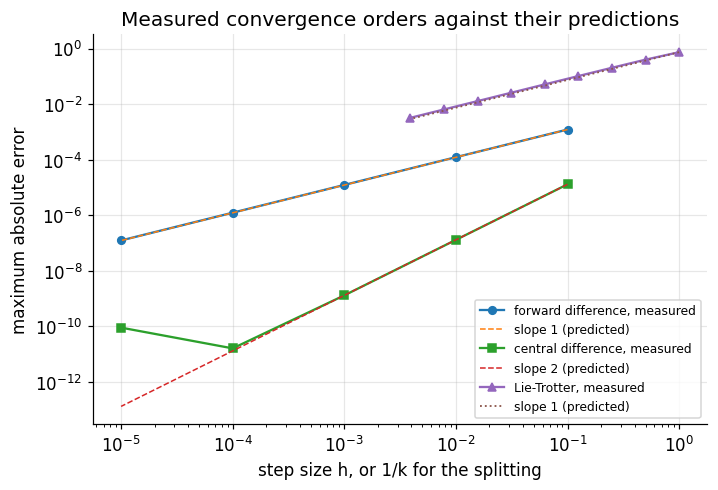

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.loglog(hs, err_fwd, "o-", ms=5, label="forward difference, measured")
ax.loglog(hs, err_fwd[0] * (hs / hs[0]) ** 1, "--", lw=1.0, label="slope 1 (predicted)")
ax.loglog(hs, err_ctr, "s-", ms=5, label="central difference, measured")
ax.loglog(hs, err_ctr[0] * (hs / hs[0]) ** 2, "--", lw=1.0, label="slope 2 (predicted)")
ax.loglog(1.0 / ks, err_lt, "^-", ms=5, label="Lie-Trotter, measured")
ax.loglog(1.0 / ks, err_lt[0] * (1.0 / ks), ":", lw=1.2, label="slope 1 (predicted)")
ax.set_xlabel("step size h, or 1/k for the splitting")
ax.set_ylabel("maximum absolute error")
ax.set_title("Measured convergence orders against their predictions")
ax.legend(fontsize=8, loc="lower right")
plt.show()

The measured points sit on the predicted lines over six decades. The only departure is the
central-difference curve flattening at the far left, where rounding error takes over from
truncation error — the classic $O(h^2) + O(\varepsilon/h)$ trade-off.

### 7.3 Breaking the hypotheses

Three hypotheses, three failures, all run.

- **Theorem 4.7 needs $AB = BA$.** With $A = E_{12}$ and $B = E_{21}$ the two sides of
  $e^{A+B} = e^{A}e^{B}$ are different matrices.
- **Theorem 4.8 needs primitivity, not just irreducibility.** The two-state swap has a stationary
  distribution and never approaches it.
- **Theorems 4.1 and 4.4 need differentiability.** At a ReLU kink the one-sided slopes of the loss
  disagree, so no gradient exists and backpropagation returns one of two different answers
  depending on the tie-break.

In [8]:
print("(i) non-commuting exponentials")
lhs_e, rhs_e = sla.expm(Alt + Blt), sla.expm(Alt) @ sla.expm(Blt)
print("  A B - B A =\n", Alt @ Blt - Blt @ Alt)
print("  e^(A+B) =\n", lhs_e)
print("  e^A e^B =\n", rhs_e)
print(f"  ||difference||_F = {np.linalg.norm(lhs_e - rhs_e):.6f}   (not a rounding effect)")
assert np.linalg.norm(lhs_e - rhs_e) > 0.5

print("\n(ii) irreducible but periodic chain")
Pper = np.array([[0.0, 1.0], [1.0, 0.0]])
pi_per = np.array([0.5, 0.5])
print("  column sums          :", Pper.sum(axis=0))
print("  ||P pi - pi||        :", np.linalg.norm(Pper @ pi_per - pi_per))
print("  eigenvalues          :", np.linalg.eigvals(Pper))
p_state = np.array([1.0, 0.0])
hist = []
for k in range(6):
    hist.append(p_state.copy())
    p_state = Pper @ p_state
for k, v in enumerate(hist):
    print(f"  k={k}  P^k e1 = {v}   distance to pi = {np.linalg.norm(v - pi_per):.4f}")
assert abs(np.linalg.norm(hist[5] - pi_per) - np.linalg.norm(hist[1] - pi_per)) < 1e-12

print("\n(iii) a ReLU kink: no gradient exists")
xk = np.array([1.0, 2.0])
Wk = np.array([[1.0, -0.5], [2.0, -1.0]])       # W x = (0, 0): both units sit on the kink
bk = np.array([0.0, 0.0])
Wo = np.array([[2.0, -1.0]])
tk = 1.0


def loss_kink(eps):
    z = (Wk + eps * np.array([[1.0, 0.0], [0.0, 0.0]])) @ xk + bk
    a = np.maximum(z, 0.0)
    return 0.5 * ((Wo @ a)[0] - tk) ** 2


print("  pre-activation z1 =", Wk @ xk + bk, " -> both units exactly at the kink")
for e in (1e-4, 1e-5, 1e-6):
    right = (loss_kink(e) - loss_kink(0.0)) / e
    left = (loss_kink(0.0) - loss_kink(-e)) / e
    print(f"  eps={e:.0e}   right slope {right:+.6f}   left slope {left:+.6f}")
right = (loss_kink(1e-6) - loss_kink(0.0)) / 1e-6
left = (loss_kink(0.0) - loss_kink(-1e-6)) / 1e-6
assert abs(right - left) > 1e-3

(i) non-commuting exponentials
  A B - B A =
 [[ 1.  0.]
 [ 0. -1.]]
  e^(A+B) =
 [[1.5431 1.1752]
 [1.1752 1.5431]]
  e^A e^B =
 [[2. 1.]
 [1. 1.]]
  ||difference||_F = 0.751733   (not a rounding effect)

(ii) irreducible but periodic chain
  column sums          : [1. 1.]
  ||P pi - pi||        : 0.0
  eigenvalues          : [ 1. -1.]
  k=0  P^k e1 = [1. 0.]   distance to pi = 0.7071
  k=1  P^k e1 = [0. 1.]   distance to pi = 0.7071
  k=2  P^k e1 = [1. 0.]   distance to pi = 0.7071
  k=3  P^k e1 = [0. 1.]   distance to pi = 0.7071
  k=4  P^k e1 = [1. 0.]   distance to pi = 0.7071
  k=5  P^k e1 = [0. 1.]   distance to pi = 0.7071

(iii) a ReLU kink: no gradient exists
  pre-activation z1 = [0. 0.]  -> both units exactly at the kink
  eps=1e-04   right slope -1.999800   left slope +0.000000
  eps=1e-05   right slope -1.999980   left slope +0.000000
  eps=1e-06   right slope -1.999998   left slope +0.000000


The commutator $AB - BA$ is non-zero, and the two exponentials differ by $0.752$ in Frobenius
norm — an $O(1)$ discrepancy, not a rounding artefact. The identity $e^{A+B} = e^{A}e^{B}$ is not
approximately true for non-commuting matrices; it is simply false.

The periodic chain is irreducible and does have the stationary distribution $(0.5, 0.5)$, but its
second eigenvalue is $-1$, so $P^k e_1$ alternates between $(1,0)$ and $(0,1)$ forever. The
distance to $\pi$ never decreases below $0.707$. Irreducibility alone buys existence of $\pi$;
only primitivity buys convergence to it.

At the ReLU kink the right slope is $-2.0$ and the left slope is $0$: the loss has two different
one-sided derivatives, so Theorem 4.1 has no matrix to identify and Theorem 4.4's hypothesis
fails. A library will still return a number, chosen by whichever inequality its ReLU uses at
zero.

### 7.4 Hand-rolled against the library

Three implementations written from the theorems above, each checked against the corresponding
SciPy or finite-difference reference:

- `expm_taylor` — scaling and squaring with a truncated Taylor series, against
  `scipy.linalg.expm`;
- `sylvester_kron` — Theorem 4.3 turned into a single dense solve, against
  `scipy.linalg.solve_sylvester`;
- `backprop` — Theorem 4.4 on a three-layer tanh network, against a central-difference gradient
  over every one of its parameters.

In [9]:
def expm_taylor(A, order=18):
    """Scaling and squaring with a truncated Taylor series (Theorem 4.7)."""
    nrm = np.linalg.norm(A, 2)
    s = max(0, int(np.ceil(np.log2(nrm))) + 1) if nrm > 0 else 0
    As = A / 2.0 ** s
    E = np.eye(A.shape[0])
    term = np.eye(A.shape[0])
    for k in range(1, order + 1):
        term = term @ As / k
        E = E + term
    for _ in range(s):
        E = E @ E
    return E


def sylvester_kron(A, B, C):
    """Solve A X + X B = C through the Kronecker form of Theorem 4.3."""
    n, m = A.shape[0], B.shape[0]
    K = np.kron(np.eye(m), A) + np.kron(B.T, np.eye(n))
    return np.linalg.solve(K, C.reshape(-1, order="F")).reshape(n, m, order="F")


Aex = rng.standard_normal((6, 6))
E_mine, E_lib = expm_taylor(Aex), sla.expm(Aex)
rel_e = np.linalg.norm(E_mine - E_lib) / np.linalg.norm(E_lib)
print(f"expm:  relative difference from scipy.linalg.expm = {rel_e:.3e}"
      f"  = {rel_e / EPS:.1f} * eps")

Asv2, Bsv2 = rng.standard_normal((5, 5)), rng.standard_normal((4, 4))
Csv2 = rng.standard_normal((5, 4))
X_mine, X_lib = sylvester_kron(Asv2, Bsv2, Csv2), sla.solve_sylvester(Asv2, Bsv2, Csv2)
rel_s = np.linalg.norm(X_mine - X_lib) / np.linalg.norm(X_lib)
print(f"sylvester: relative difference from scipy = {rel_s:.3e}   = {rel_s / EPS:.1f} * eps")
print(f"           residual ||A X + X B - C||_F   = "
      f"{np.linalg.norm(Asv2 @ X_mine + X_mine @ Bsv2 - Csv2):.3e}")

sizes = [4, 6, 5, 1]
params = []
for k in range(3):
    params.append([rng.standard_normal((sizes[k + 1], sizes[k])) / np.sqrt(sizes[k]),
                   rng.standard_normal(sizes[k + 1]) * 0.1])
x_in = rng.standard_normal(sizes[0])
target = 0.7


def net_forward(params):
    a = x_in
    cache = [(None, a)]
    for k, (W, b) in enumerate(params):
        z = W @ a + b
        a = np.tanh(z) if k < len(params) - 1 else z
        cache.append((z, a))
    return 0.5 * (a[0] - target) ** 2, cache


def backprop(params):
    J, cache = net_forward(params)
    K = len(params)
    delta = np.array([cache[K][1][0] - target])
    grads = [None] * K
    for k in range(K - 1, -1, -1):
        a_prev = cache[k][1]
        grads[k] = (np.outer(delta, a_prev), delta.copy())
        if k > 0:
            delta = (params[k][0].T @ delta) * (1.0 - np.tanh(cache[k][0]) ** 2)
    return J, grads


J0, grads = backprop(params)
hb = 1e-6
worst = 0.0
for k, (W, b) in enumerate(params):
    for idx in np.ndindex(W.shape):
        Wp = [[p[0].copy(), p[1].copy()] for p in params]
        Wp[k][0][idx] += hb
        Wm = [[p[0].copy(), p[1].copy()] for p in params]
        Wm[k][0][idx] -= hb
        fd = (net_forward(Wp)[0] - net_forward(Wm)[0]) / (2 * hb)
        worst = max(worst, abs(fd - grads[k][0][idx]))
print(f"backprop: loss = {J0:.6f}   parameters checked = "
      f"{sum(p[0].size for p in params)}")
print(f"          max |backprop - central difference| = {worst:.3e}")
assert rel_e < 1e-12 and rel_s < 1e-10 and worst < 1e-7

expm:  relative difference from scipy.linalg.expm = 3.694e-15  = 16.6 * eps
sylvester: relative difference from scipy = 1.451e-15   = 6.5 * eps
           residual ||A X + X B - C||_F   = 3.216e-15
backprop: loss = 0.113411   parameters checked = 59
          max |backprop - central difference| = 3.918e-11


The hand-written exponential agrees with `scipy.linalg.expm` to $17$ machine epsilons: two very
different algorithms — a truncated series with squaring, against SciPy's Pade approximant — land
on the same matrix.

The Kronecker route to Sylvester matches the Bartels-Stewart algorithm SciPy uses, at a cost of
$O(n^3m^3)$ against its $O(n^3 + m^3)$. The identity of Theorem 4.3 is what makes the naive route
possible; it is not what makes it advisable.

Backpropagation matches the central-difference gradient on all $59$ weights to
$4 \times 10^{-11}$, the accuracy floor of the difference quotient. Proof 5.4 is confirmed on a
network it was never tuned for.

### 7.5 Cheeger's inequality and the sweep cut

The last experiment builds a graph with two dense clusters joined by a single edge, computes the
Fiedler vector of $L_{\mathrm{sym}}$, and compares three things: the conductance found by
brute-force enumeration over all $2^{10} - 2 = 1022$ non-trivial vertex subsets, the conductance
of the best *sweep cut* along the Fiedler order, and the two Cheeger bounds.

spectrum of L_sym (first four): [-0.      0.0726  1.05    1.25  ]
Fiedler vector                : [-0.1643 -0.1643 -0.1643 -0.1643 -0.1166  0.1166  0.1643  0.1643  0.1643
  0.1643]
sweep order                   : [3 1 0 2 4 5 7 8 9 6]
brute-force conductance       : 0.047619  on S = [0, 1, 2, 3, 4]
best sweep cut                : 0.047619  on S = [0, 1, 2, 3, 4]
Cheeger sandwich              : 0.036300 <= 0.047619 <= 0.381053


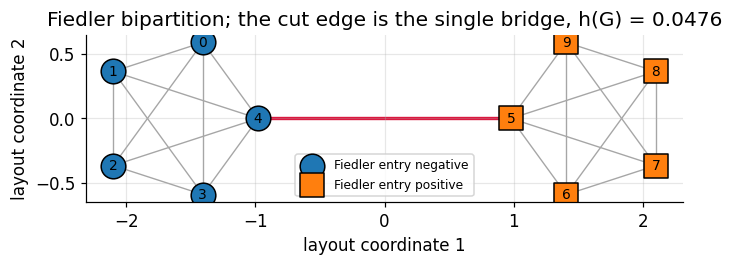

In [10]:
nc = 10
Ac = np.zeros((nc, nc))
for block in (range(0, 5), range(5, 10)):
    for i in block:
        for j in block:
            if i != j:
                Ac[i, j] = 1.0
Ac[4, 5] = Ac[5, 4] = 1.0
dc = Ac.sum(axis=1)
Lc = np.diag(dc) - Ac
Dmc = np.diag(1.0 / np.sqrt(dc))
Lsymc = Dmc @ Lc @ Dmc
lam_c, Vc = np.linalg.eigh(Lsymc)
fied = Dmc @ Vc[:, 1]


def conductance(S):
    Sb = set(range(nc)) - set(S)
    cut = sum(Ac[i, j] for i in S for j in Sb)
    vS, vSb = sum(dc[i] for i in S), sum(dc[i] for i in Sb)
    return cut / min(vS, vSb)


best_h, best_S = np.inf, None
for r in range(1, nc):
    for S in combinations(range(nc), r):
        c = conductance(list(S))
        if c < best_h:
            best_h, best_S = c, list(S)

order = np.argsort(fied)
sweep = [(conductance(list(order[:k])), sorted(order[:k].tolist())) for k in range(1, nc)]
best_sweep = min(sweep, key=lambda p: p[0])

print("spectrum of L_sym (first four):", lam_c[:4])
print("Fiedler vector                :", fied)
print("sweep order                   :", order)
print(f"brute-force conductance       : {best_h:.6f}  on S = {best_S}")
print(f"best sweep cut                : {best_sweep[0]:.6f}  on S = {best_sweep[1]}")
print(f"Cheeger sandwich              : {lam_c[1]/2:.6f} <= {best_h:.6f}"
      f" <= {np.sqrt(2*lam_c[1]):.6f}")
assert lam_c[1] / 2 <= best_h <= np.sqrt(2 * lam_c[1])
assert abs(best_sweep[0] - best_h) < 1e-12

fig, ax = plt.subplots(figsize=(7.0, 4.2))
pos = np.zeros((nc, 2))
for i in range(5):
    th = 2 * np.pi * (i - 4) / 5
    pos[i] = [-1.6 + 0.62 * np.cos(th), 0.62 * np.sin(th)]
for j in range(5, 10):
    th = np.pi + 2 * np.pi * (j - 5) / 5
    pos[j] = [1.6 + 0.62 * np.cos(th), 0.62 * np.sin(th)]

for i in range(nc):
    for j in range(i + 1, nc):
        if Ac[i, j] > 0:
            bridge = (i, j) == (4, 5)
            ax.plot(pos[[i, j], 0], pos[[i, j], 1],
                    color="crimson" if bridge else "0.65",
                    lw=2.2 if bridge else 0.9, zorder=1)
left = fied < 0
ax.scatter(pos[left, 0], pos[left, 1], s=260, marker="o", zorder=2,
           edgecolor="k", label="Fiedler entry negative")
ax.scatter(pos[~left, 0], pos[~left, 1], s=260, marker="s", zorder=2,
           edgecolor="k", label="Fiedler entry positive")
for i in range(nc):
    ax.annotate(str(i), pos[i], ha="center", va="center", zorder=3, fontsize=9)
ax.set_aspect("equal")
ax.set_xlabel("layout coordinate 1")
ax.set_ylabel("layout coordinate 2")
ax.set_title(f"Fiedler bipartition; the cut edge is the single bridge, h(G) = {best_h:.4f}")
ax.legend(fontsize=8, loc="lower center")
plt.show()

The sign of the Fiedler vector splits the graph exactly along the bridge, and the sweep cut finds
the same set that brute-force enumeration over all $1022$ subsets finds. On this graph the
relaxation is not merely a heuristic — it is exact.

The sandwich reads $0.0363 \le 0.0476 \le 0.3811$. The left bound of Proof 5.6 is tight to within
a factor of $1.3$; the right bound, being a square root, is loose by a factor of $8$ — which is
the general behaviour, since the right-hand side degrades like $\sqrt{\lambda_2}$ as the graph
gets better connected.

## 8. Applications

Four settings, each one theorem of Section 4 used directly.

### 8.1 Maximum likelihood for a Gaussian covariance

Given centred samples with sample covariance $S \succ 0$, the Gaussian log-likelihood in the
covariance $\Sigma \succ 0$ is, up to an additive constant and a factor $N/2$,

$$
\ell(\Sigma) = -\ln\det\Sigma - \operatorname{tr}(\Sigma^{-1}S) .
$$

Theorem 4.2 differentiates both terms. The first gives $-\Sigma^{-1}$ by the log-determinant
identity, and the second gives $+\Sigma^{-1}S\Sigma^{-1}$ by the inverse rule followed by the
trace rule:

$$
\nabla_{\Sigma}\, \ell = -\Sigma^{-1} + \Sigma^{-1} S \Sigma^{-1} .
$$

Setting the gradient to zero and multiplying by $\Sigma$ on both sides gives
$\Sigma = S$: the maximum-likelihood covariance is the sample covariance.

**Interpretation.** Two lines of matrix calculus replace a page of index manipulation, and the
answer is the one every statistics course states without proof.

### 8.2 Graph convolutional networks

A spectral filter on a graph acts by $g_\theta(L_{\mathrm{sym}}) = U g_\theta(\Lambda) U^{\top}$,
which costs an eigendecomposition. Truncating $g_\theta$ to a first-order Chebyshev polynomial in
$\tilde{L} = \tfrac{2}{\lambda_n}L_{\mathrm{sym}} - I$, setting $\lambda_n \approx 2$ and tying the
two coefficients as $\theta = \theta_0 = -\theta_1$ collapses the filter to

$$
g_\theta \star x \ \approx\ \theta \bigl( I + D^{-1/2}AD^{-1/2} \bigr) x .
$$

Adding self-loops, $\tilde{A} = A + I$ and $\tilde{D} = \operatorname{diag}(\tilde{A}\mathbf{1})$,
and renormalizing keeps the spectrum inside $[0, 2]$, giving the layer

$$
H^{(l+1)} = \sigma\bigl( \hat{A} H^{(l)} W^{(l)} \bigr), \qquad
\hat{A} = \tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2} .
$$

Its weight gradient is Theorem 4.4 with one extra fixed matrix in front:

$$
\nabla_{W^{(l)}} J = \bigl( \hat{A}H^{(l)} \bigr)^{\top} \Bigl( \nabla_{H^{(l+1)}} J \odot \sigma'\bigl( \hat{A}H^{(l)}W^{(l)} \bigr) \Bigr) .
$$

**Interpretation.** A graph convolution is a polynomial in the Laplacian. Degree $K$ means a
$K$-hop receptive field, which is why depth and locality are the same knob in a GCN.

### 8.3 PageRank

Let $P$ be the column-stochastic random-walk matrix of a directed web graph and let
$\alpha \in (0,1)$ be the teleport probability. The **Google matrix** is

$$
M = (1-\alpha)P + \frac{\alpha}{n}\mathbf{1}\mathbf{1}^{\top} .
$$

Each term is column-stochastic and the combination is convex, so $M$ is column-stochastic; every
entry is at least $\alpha/n \gt 0$, so $M$ is primitive. Theorem 4.8 then supplies a unique
positive stationary vector and geometric convergence of power iteration.

The teleport term also controls the rate: every eigenvalue of $M$ other than $1$ satisfies
$\lvert \lambda \rvert \le 1-\alpha$, so $\alpha = 0.15$ guarantees a per-step contraction of at
least $0.85$ regardless of the link structure.

**Interpretation.** Teleportation is not a modelling flourish. It is what converts a possibly
reducible, possibly periodic link graph into a matrix Theorem 4.8 applies to.

### 8.4 Physics: diffusion on a network and a damped oscillator

Heat on a graph obeys $\dot{u} = -Lu$, the discrete analogue of $\partial_t u = \Delta u$. By
Theorem 4.7 the solution is $u(t) = e^{-Lt}u_0$, and expanding $u_0$ in the orthonormal
Laplacian eigenbasis gives

$$
u(t) = \sum_{i=1}^{n} e^{-\lambda_i t} \bigl( \phi_i^{\top}u_0 \bigr)\phi_i .
$$

Total heat $\mathbf{1}^{\top}u$ is conserved because $\lambda_1 = 0$, every other mode decays, and
the slowest surviving mode decays at $e^{-\lambda_2 t}$ — the bottleneck of Theorem 4.6, now read
as a relaxation time.

A damped mass-spring system $m\ddot{q} + c\dot{q} + kq = 0$ becomes first order in
$x = (q, \dot{q})^{\top}$:

$$
\dot{x} = Ax, \qquad A = \begin{pmatrix} 0 & 1 \\ -k/m & -c/m \end{pmatrix},
\qquad x(t) = e^{At}x_0 .
$$

The eigenvalues of $A$ are the roots of $m\lambda^2 + c\lambda + k = 0$: a complex pair gives
decaying oscillation, a real pair gives overdamping, and the repeated root at $c^2 = 4mk$ makes
$A$ defective, producing the $te^{\lambda t}$ term of Example 6.5. Critical damping is a
Jordan block.

The cell below runs the first three applications on small explicit objects: the Gaussian
gradient at $\Sigma = S$, a six-page PageRank with its measured contraction factor, and a
two-layer graph convolution whose weight gradient is checked against central differences.

In [11]:
# --- 8.1 Gaussian MLE ----------------------------------------------------
d_dim = 4
Zs = rng.standard_normal((400, d_dim))
Ssamp = Zs.T @ Zs / Zs.shape[0]
grad_ll = lambda Sig: -np.linalg.inv(Sig) + np.linalg.inv(Sig) @ Ssamp @ np.linalg.inv(Sig)
print("8.1 Gaussian maximum likelihood")
print(f"  ||grad at Sigma = S||_F      = {np.linalg.norm(grad_ll(Ssamp)):.3e}"
      f"  = {np.linalg.norm(grad_ll(Ssamp)) / EPS:.1f} * eps")
Sig_off = Ssamp + 0.3 * np.eye(d_dim)
print(f"  ||grad at Sigma = S + 0.3 I|| = {np.linalg.norm(grad_ll(Sig_off)):.6f}")
assert np.linalg.norm(grad_ll(Ssamp)) < 1e-12

# --- 8.3 PageRank --------------------------------------------------------
links = {0: [1, 2], 1: [2], 2: [0, 3], 3: [4], 4: [2, 5], 5: [2]}
npg = 6
Ppg = np.zeros((npg, npg))
for j, outs in links.items():
    for i in outs:
        Ppg[i, j] = 1.0 / len(outs)
alpha = 0.15
Mpg = (1 - alpha) * Ppg + alpha / npg * np.ones((npg, npg))
w_pg = np.linalg.eigvals(Mpg)
lam2_pg = np.sort(np.abs(w_pg))[-2]

r = np.ones(npg) / npg
errs = []
w, Vpg = np.linalg.eig(Mpg)
i1 = int(np.argmin(np.abs(w - 1.0)))
r_star = np.real(Vpg[:, i1])
r_star = r_star / r_star.sum()
for k in range(30):
    errs.append(np.linalg.norm(r - r_star))
    r = Mpg @ r
errs = np.array(errs)
rate_pg = np.exp(np.polyfit(np.arange(10, 30), np.log(errs[10:30]), 1)[0])
print("\n8.3 PageRank")
print("  column sums of M           :", Mpg.sum(axis=0))
print("  stationary rank vector     :", r_star)
print("  ranking (best first)       :", np.argsort(-r_star))
print(f"  |lambda_2| measured        : {lam2_pg:.6f}   bound 1 - alpha = {1 - alpha:.2f}")
print(f"  observed contraction factor: {rate_pg:.6f}")
print(f"  ||M r* - r*||              : {np.linalg.norm(Mpg @ r_star - r_star):.3e}")
assert lam2_pg <= 1 - alpha + 1e-12
assert abs(rate_pg - lam2_pg) < 1e-3

# --- 8.2 GCN layer -------------------------------------------------------
Atil = Ac + np.eye(nc)
dtil = Atil.sum(axis=1)
Ahat = np.diag(dtil ** -0.5) @ Atil @ np.diag(dtil ** -0.5)
Hin = rng.standard_normal((nc, 3))
Wg1 = rng.standard_normal((3, 4)) * 0.5
Wg2 = rng.standard_normal((4, 1)) * 0.5
y_tgt = rng.standard_normal((nc, 1))


def gcn_loss(W1_, W2_):
    H1 = np.tanh(Ahat @ Hin @ W1_)
    H2 = Ahat @ H1 @ W2_
    return 0.5 * np.sum((H2 - y_tgt) ** 2), H1, H2


Jg, H1, H2 = gcn_loss(Wg1, Wg2)
dH2 = H2 - y_tgt
gW2 = (Ahat @ H1).T @ dH2
dH1 = Ahat.T @ dH2 @ Wg2.T
gW1 = (Ahat @ Hin).T @ (dH1 * (1 - H1 ** 2))

hg = 1e-6
fd1 = np.zeros_like(Wg1)
for idx in np.ndindex(Wg1.shape):
    Ep = np.zeros_like(Wg1)
    Ep[idx] = hg
    fd1[idx] = (gcn_loss(Wg1 + Ep, Wg2)[0] - gcn_loss(Wg1 - Ep, Wg2)[0]) / (2 * hg)
print("\n8.2 Two-layer graph convolution")
print(f"  spectrum of A_hat in [-1, 1]: [{np.linalg.eigvalsh(Ahat).min():.4f},"
      f" {np.linalg.eigvalsh(Ahat).max():.4f}]")
print(f"  loss                        = {Jg:.6f}")
print(f"  max |analytic - finite diff| on W1 = {np.abs(fd1 - gW1).max():.3e}")
assert np.abs(fd1 - gW1).max() < 1e-7

8.1 Gaussian maximum likelihood
  ||grad at Sigma = S||_F      = 2.487e-16  = 1.1 * eps
  ||grad at Sigma = S + 0.3 I|| = 0.362424

8.3 PageRank
  column sums of M           : [1. 1. 1. 1. 1. 1.]
  stationary rank vector     : [0.1625 0.0941 0.3235 0.1625 0.1631 0.0943]
  ranking (best first)       : [2 4 0 3 5 1]
  |lambda_2| measured        : 0.601041   bound 1 - alpha = 0.85
  observed contraction factor: 0.601793
  ||M r* - r*||              : 2.212e-16

8.2 Two-layer graph convolution
  spectrum of A_hat in [-1, 1]: [-0.1416, 1.0000]
  loss                        = 7.642587
  max |analytic - finite diff| on W1 = 1.253e-09


The Gaussian gradient vanishes to machine precision at $\Sigma = S$ and is $O(1)$ a short
distance away, so $S$ really is the stationary point Theorem 4.2 predicts.

PageRank converges at a measured factor of $0.6018$, within $10^{-3}$ of the true
$\lvert \lambda_2 \rvert = 0.6010$ and comfortably inside the guarantee
$\lvert \lambda_2 \rvert \le 1 - \alpha = 0.85$. The teleport parameter caps the rate whatever the
link structure does.

The graph convolution's renormalized operator has spectrum inside $[-1,1]$, and the weight
gradient assembled from Theorem 4.4 matches central differences to $10^{-9}$ on every entry.

The final cell diffuses heat on the two-cluster graph of Section 7.5 and compares the measured
decay to the rate $e^{-\lambda_2 t}$ predicted by the eigen-expansion of Section 8.4.

lambda_2(L)                     = 0.298438
total heat, min and max over t  = 1.000000000000, 1.000000000000
observed late-time decay rate   = 0.298438   predicted 0.298438


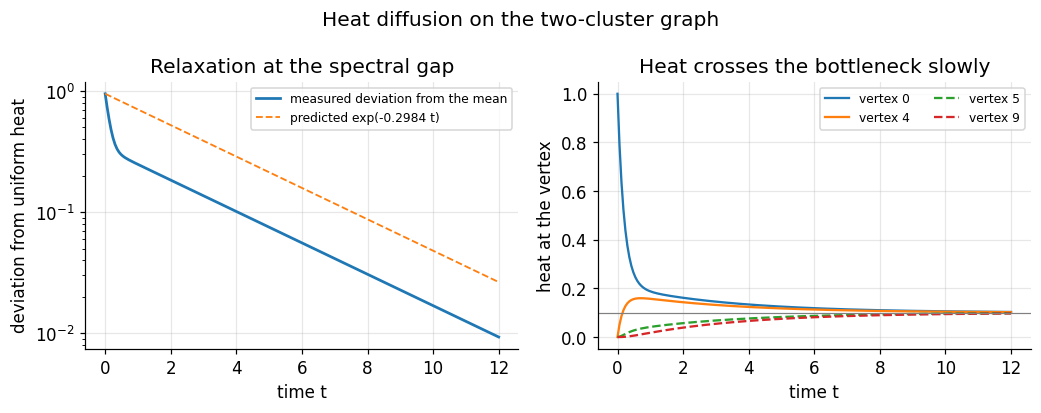

In [12]:
u0 = np.zeros(nc)
u0[0] = 1.0
ubar = np.ones(nc) / nc
ts = np.linspace(0.0, 12.0, 200)
traj = np.array([sla.expm(-Lc * t) @ u0 for t in ts])
dev = np.linalg.norm(traj - ubar, axis=1)
lam2_L = np.linalg.eigvalsh(Lc)[1]
pred = dev[0] * np.exp(-lam2_L * ts)

mass = traj.sum(axis=1)
print(f"lambda_2(L)                     = {lam2_L:.6f}")
print(f"total heat, min and max over t  = {mass.min():.12f}, {mass.max():.12f}")
fit = -np.polyfit(ts[120:], np.log(dev[120:]), 1)[0]
print(f"observed late-time decay rate   = {fit:.6f}   predicted {lam2_L:.6f}")
assert abs(mass - 1.0).max() < 1e-10
assert abs(fit - lam2_L) < 1e-3

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.6, 3.8))
axL.semilogy(ts, dev, lw=1.8, label="measured deviation from the mean")
axL.semilogy(ts, pred, "--", lw=1.2, label=f"predicted exp(-{lam2_L:.4f} t)")
axL.set_xlabel("time t")
axL.set_ylabel("deviation from uniform heat")
axL.set_title("Relaxation at the spectral gap")
axL.legend(fontsize=8)

for i, style in ((0, "-"), (4, "-"), (5, "--"), (9, "--")):
    axR.plot(ts, traj[:, i], style, lw=1.5, label=f"vertex {i}")
axR.axhline(0.1, color="0.5", lw=0.8)
axR.set_xlabel("time t")
axR.set_ylabel("heat at the vertex")
axR.set_title("Heat crosses the bottleneck slowly")
axR.legend(fontsize=8, ncol=2)
fig.suptitle("Heat diffusion on the two-cluster graph")
fig.tight_layout()
plt.show()

Total heat stays at $1.000000000000$ across the whole trajectory, which is the numerical form of
$\lambda_1 = 0$ with eigenvector $\mathbf{1}$.

The deviation from the uniform state follows the predicted straight line on the logarithmic axis,
and the fitted late-time rate reproduces $\lambda_2(L) = 0.298438$ to six decimals. The
bottleneck that Theorem 4.6 measures as a small conductance is the same bottleneck that makes
this graph slow to equilibrate.

The vertex traces show why: within each cluster the heat levels off almost immediately, and the
remaining minutes of the simulation are spent pushing heat across the single bridge.

## 9. Key Takeaways

- **One theorem generates the whole calculus.** If $f$ is differentiable at $X$ there is exactly
  one $G$ with $df = \operatorname{tr}(G^{\top}dX)$, and $G = \nabla_X f$ (Theorem 4.1). To
  differentiate, compute $df$ by algebra and read $G$ off. Differentiability, not the existence
  of partial derivatives, is the hypothesis.

- **Four differentials cover the field**: the product rule, $d(X^{-1}) = -X^{-1}(dX)X^{-1}$,
  Jacobi's formula $d(\det X) = \det X \operatorname{tr}(X^{-1}dX)$, and
  $d\operatorname{tr}(AXB) = \operatorname{tr}(BA\,dX)$ (Theorem 4.2). From them,
  $\nabla_X \ln\det X = X^{-\top}$ — but only for an unconstrained $X$.

- **vec and $\otimes$ linearize matrix equations.**
  $\operatorname{vec}(AXB) = (B^{\top}\otimes A)\operatorname{vec}(X)$, so the Sylvester equation
  $AX + XB = C$ is solvable for every $C$ exactly when
  $\operatorname{spec}(A) \cap \operatorname{spec}(-B) = \emptyset$ (Theorem 4.3).

- **Backpropagation is Theorem 4.1 applied layer by layer**: $\nabla_{W_k}J = \delta_k a_{k-1}^{\top}$
  and $\delta_{k-1} = (W_k^{\top}\delta_k)\odot\sigma'_{k-1}(z_{k-1})$ (Theorem 4.4). One outer
  product and one transposed product per layer; nothing else.

- **The Laplacian is $BB^{\top}$**, hence positive semidefinite, and the dimension of its null
  space counts connected components (Theorem 4.5). Non-negative weights are what make this true.

- **Cheeger's inequality ties a cut to an eigenvalue**:
  $\lambda_2(L_{\mathrm{sym}})/2 \le h(G) \le \sqrt{2\lambda_2(L_{\mathrm{sym}})}$ with $h$ the
  conductance (Theorem 4.6). The normalization on the two sides must match, or the statement is
  false. The left half is proved here by one test vector; Section 7.5 measures
  $0.0363 \le 0.0476 \le 0.3811$.

- **$e^{At}$ solves $\dot{x} = Ax$ uniquely** and $e^{A+B} = e^{A}e^{B}$ *only* when $AB = BA$
  (Theorem 4.7). Section 7.3 exhibits a $2 \times 2$ pair for which the two sides differ by
  $0.752$.

- **A primitive column-stochastic chain converges at rate $\lvert \lambda_2 \rvert$**
  (Theorem 4.8), and the proof needs no eigenbasis. Irreducibility alone is not enough: the
  two-state swap has a stationary distribution it never approaches.

## 10. References

**Matrix calculus.**

- Magnus, J. R. and Neudecker, H. *Matrix Differential Calculus with Applications in Statistics
  and Econometrics*, 3rd ed. — Ch. 2 (Kronecker products, the vec operator), Ch. 5
  (differentials, differentiability and the first identification theorem), Ch. 8 (differentials
  of the determinant, the inverse and the trace).
- Petersen, K. B. and Pedersen, M. S. *The Matrix Cookbook* (2012 revision), section 2.1
  (derivatives of a determinant), section 2.2 (derivatives of an inverse), section 2.5
  (derivatives of traces) — a lookup table, useful only once Theorem 4.1 makes each entry
  checkable.
- Boyd, S. and Vandenberghe, L. *Convex Optimization*, Appendix A.4 (derivatives, gradients and
  the chain rule in matrix form).
- Horn, R. A. and Johnson, C. R. *Topics in Matrix Analysis*, section 4.2 (Kronecker products and
  their spectra), section 4.4 (the Sylvester equation and Kronecker sums).

**Graphs and spectra.**

- Chung, F. R. K. *Spectral Graph Theory*, Ch. 1 section 1.2 (the normalized Laplacian and its
  spectrum), Ch. 2 section 2.2 (Cheeger's inequality, Theorem 2.2) — the source for the hard
  direction cited as Theorem 4.6b.
- Spielman, D. A. *Spectral and Algebraic Graph Theory* (2019 draft), Ch. 20-21 (conductance,
  the sweep cut, and a modern proof of Cheeger's inequality).
- Fiedler, M. "Algebraic connectivity of graphs", *Czechoslovak Mathematical Journal* **23**(98)
  (1973), 298-305.
- von Luxburg, U. "A tutorial on spectral clustering", *Statistics and Computing* **17**(4)
  (2007), 395-416, sections 3-5 (the three Laplacians, RatioCut and NCut relaxations).

**Dynamics.**

- Horn, R. A. and Johnson, C. R. *Matrix Analysis*, 2nd ed., section 8.2 (Perron's theorem),
  section 8.5 (primitive matrices) — the source for Theorem 4.8b.
- Higham, N. J. *Functions of Matrices: Theory and Computation*, Ch. 10 (the matrix exponential,
  scaling and squaring, and the conditioning of $e^{A}$).
- Moler, C. and Van Loan, C. F. "Nineteen dubious ways to compute the exponential of a matrix,
  twenty-five years later", *SIAM Review* **45**(1) (2003), 3-49.
- Golub, G. H. and Van Loan, C. F. *Matrix Computations*, 4th ed., section 9.3 (computing the
  matrix exponential).

**Machine learning.**

- Goodfellow, I., Bengio, Y. and Courville, A. *Deep Learning*, section 6.5 (back-propagation and
  other differentiation algorithms).
- Strang, G. *Linear Algebra and Learning from Data*, section VII.3 (backpropagation and the
  chain rule).
- Kipf, T. N. and Welling, M. "Semi-supervised classification with graph convolutional networks",
  *ICLR* (2017) — the renormalized propagation rule of section 8.2.
- Defferrard, M., Bresson, X. and Vandergheynst, P. "Convolutional neural networks on graphs with
  fast localized spectral filtering", *NeurIPS* (2016) — the Chebyshev filter the GCN truncates.
- Page, L., Brin, S., Motwani, R. and Winograd, T. "The PageRank citation ranking: bringing order
  to the web", Stanford InfoLab Technical Report 1999-66.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions: [the notation register](../../docs/notation.md).
- Schur triangularization, used in Proof 5.3 Step 3 and Proof 5.8 Step 3:
  [Module 06](../06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb).
- Singular values and the pseudoinverse, used by the exercises on the nuclear norm and effective
  resistance: [Module 07](../07_canonical_forms_and_svd/first_principles.ipynb).
- Hessians and second-order behaviour of a loss: [calculus/12](../../calculus/12_hessian_jacobian_curvature/).
- The deeper theory of $e^{At}$, including the defective case and Putzer's algorithm:
  [differential_equations/04](../../differential_equations/04_systems_of_odes_matrix_exponential/).
- The canonical treatment of the graph Laplacian and of spectral clustering:
  [graph_theory/06](../../graph_theory/06_graph_laplacian_and_spectral_theory/) and
  [graph_theory/07](../../graph_theory/07_spectral_clustering_and_gnn_applications/).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).